In [1]:
# Cell 1: FIXED - Use absolute path
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Absolute path to database
DB_PATH = r'C:\Users\Sarthak\Documents\ML\fighter-beta\mma_fighters.db'

conn = sqlite3.connect(DB_PATH)

print("✅ Connected to database")
print(f"Database: {DB_PATH}")

# Quick test - list tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f"\n✅ Found {len(tables)} tables:")
print(tables.to_string(index=False))

C:\Users\Sarthak\miniconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ Connected to database
Database: C:\Users\Sarthak\Documents\ML\fighter-beta\mma_fighters.db

✅ Found 10 tables:
                         name
                  fighters_v2
                    fights_v2
            fight_fighters_v2
              fight_rounds_v2
         fight_round_stats_v2
   fight_round_sig_strikes_v2
              fight_totals_v2
ingestion_fighter_progress_v2
                   fight_odds
         odds_scrape_progress


In [2]:
# Cell 2: Quick data exploration
print("=== DATABASE OVERVIEW ===\n")

# Count records
fighters = pd.read_sql("SELECT COUNT(*) as count FROM fighters_v2 WHERE is_stub = 0", conn)
fights = pd.read_sql("SELECT COUNT(*) as count FROM fights_v2", conn)
rounds = pd.read_sql("SELECT COUNT(*) as count FROM fight_round_stats_v2", conn)
odds = pd.read_sql("SELECT COUNT(*) as count FROM fight_odds", conn)

print(f"Fighters: {fighters['count'][0]:,}")
print(f"Fights: {fights['count'][0]:,}")
print(f"Round Stats: {rounds['count'][0]:,}")
print(f"Fights with Odds: {odds['count'][0]:,}")

# Sample recent fight
print("\n=== SAMPLE RECENT FIGHT ===\n")
sample = pd.read_sql("""
    SELECT 
        f.event_name,
        f.event_date,
        f1.name as fighter_1,
        f2.name as fighter_2,
        ff1.result as f1_result
    FROM fights_v2 f
    JOIN fight_fighters_v2 ff1 ON f.fight_id = ff1.fight_id AND ff1.corner = 'fighter_1'
    JOIN fighters_v2 f1 ON ff1.fighter_id = f1.fighter_id
    JOIN fight_fighters_v2 ff2 ON f.fight_id = ff2.fight_id AND ff2.corner = 'fighter_2'
    JOIN fighters_v2 f2 ON ff2.fighter_id = f2.fighter_id
    WHERE f.event_date >= '2024-01-01'
    ORDER BY f.event_date DESC
    LIMIT 5
""", conn)

print(sample.to_string(index=False))

=== DATABASE OVERVIEW ===

Fighters: 4,451
Fights: 11,127
Round Stats: 48,772
Fights with Odds: 8,221

=== SAMPLE RECENT FIGHT ===

                            event_name event_date            fighter_1           fighter_2 f1_result
UFC Fight Night: Bautista vs. Oliveira 2026-02-07       Klaudia Sygula  Priscila Cachoeira       win
UFC Fight Night: Bautista vs. Oliveira 2026-02-07      Kyoji Horiguchi         Amir Albazi       win
UFC Fight Night: Bautista vs. Oliveira 2026-02-07 Marc-Andre Barriault Michal Oleksiejczuk      loss
UFC Fight Night: Bautista vs. Oliveira 2026-02-07       Mario Bautista   Vinicius Oliveira       win
UFC Fight Night: Bautista vs. Oliveira 2026-02-07         Muin Gafurov       Jakub Wiklacz      loss


In [3]:
# Cell 3: Extract striking accuracy for all fighters in all rounds
query = """
SELECT 
    f.fighter_id,
    f.name as fighter_name,
    fight.event_date,
    fight.weight_class,
    frs.sig_str_landed,
    frs.sig_str_attempted,
    CASE 
        WHEN frs.sig_str_attempted > 0 
        THEN CAST(frs.sig_str_landed AS FLOAT) / frs.sig_str_attempted 
        ELSE NULL 
    END as striking_accuracy
FROM fight_round_stats_v2 frs
JOIN fight_rounds_v2 fr ON frs.round_id = fr.round_id
JOIN fights_v2 fight ON fr.fight_id = fight.fight_id
JOIN fighters_v2 f ON frs.fighter_id = f.fighter_id
WHERE frs.sig_str_attempted > 0  -- Only rounds with striking
  AND fight.event_date >= '2010-01-01'  -- Focus on modern era
ORDER BY fight.event_date DESC
"""

striking_data = pd.read_sql(query, conn)

print(f"✅ Loaded {len(striking_data):,} round-level striking accuracy records")
print(f"\nDate range: {striking_data['event_date'].min()} to {striking_data['event_date'].max()}")
print(f"\nSample data:")
print(striking_data.head(10))

✅ Loaded 39,080 round-level striking accuracy records

Date range: 2010-01-02 to 2026-02-07

Sample data:
         fighter_id          fighter_name  event_date  \
0  9f5e3c20ce40b344        Klaudia Sygula  2026-02-07   
1  9f5e3c20ce40b344        Klaudia Sygula  2026-02-07   
2  9f5e3c20ce40b344        Klaudia Sygula  2026-02-07   
3  98aa60cf58071fd6       Kyoji Horiguchi  2026-02-07   
4  98aa60cf58071fd6       Kyoji Horiguchi  2026-02-07   
5  98aa60cf58071fd6       Kyoji Horiguchi  2026-02-07   
6  8e9eb3fc86db0f7d  Marc-Andre Barriault  2026-02-07   
7  8e9eb3fc86db0f7d  Marc-Andre Barriault  2026-02-07   
8  8e9eb3fc86db0f7d  Marc-Andre Barriault  2026-02-07   
9  bc711b6dd95c1af6        Mario Bautista  2026-02-07   

                weight_class  sig_str_landed  sig_str_attempted  \
0  Women's Bantamweight Bout              61                136   
1  Women's Bantamweight Bout              40                 94   
2  Women's Bantamweight Bout              50                105  

=== STRIKING ACCURACY DISTRIBUTION ===

Mean accuracy: 45.9%
Median accuracy: 45.2%
Std dev: 0.176

=== BY WEIGHT CLASS ===

                          count   mean  median    std
weight_class                                         
Lightweight Bout           5961  0.447   0.439  0.173
Welterweight Bout          5434  0.456   0.450  0.174
Featherweight Bout         4490  0.454   0.444  0.174
Middleweight Bout          4295  0.468   0.467  0.184
Bantamweight Bout          4025  0.447   0.441  0.172
Light Heavyweight Bout     2534  0.482   0.480  0.184
Heavyweight Bout           2473  0.487   0.485  0.192
Flyweight Bout             2104  0.446   0.432  0.172
Women's Strawweight Bout   1921  0.460   0.452  0.163
Women's Flyweight Bout     1389  0.453   0.442  0.157


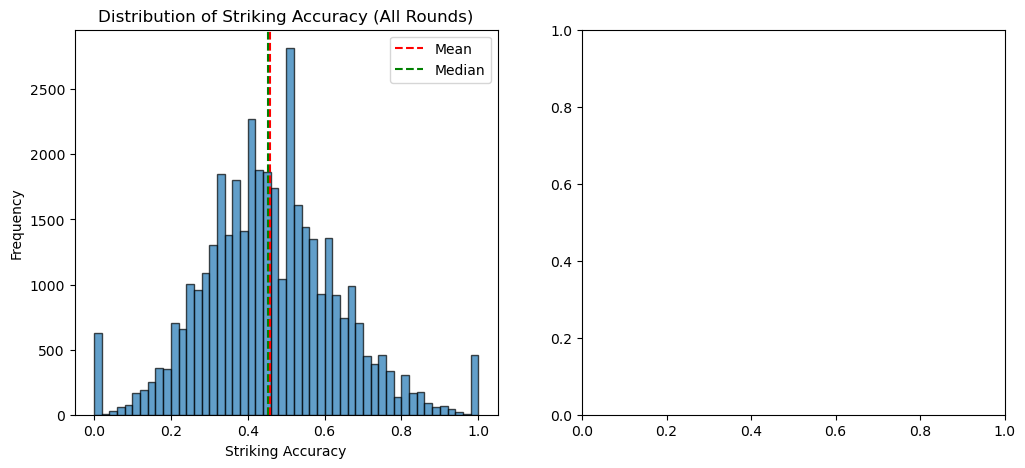

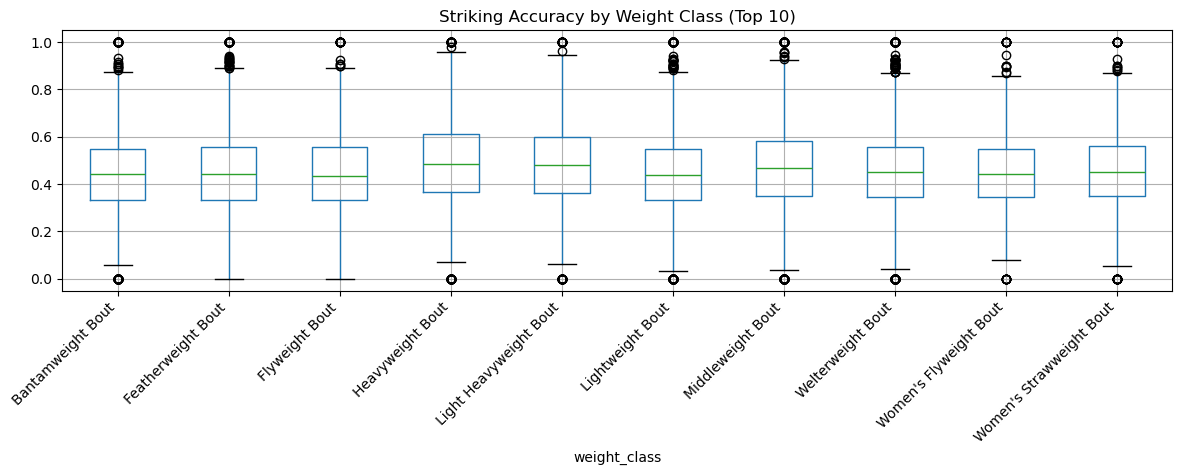

In [4]:
# Cell 4: Explore striking accuracy distribution
print("=== STRIKING ACCURACY DISTRIBUTION ===\n")

# Overall stats
print(f"Mean accuracy: {striking_data['striking_accuracy'].mean():.1%}")
print(f"Median accuracy: {striking_data['striking_accuracy'].median():.1%}")
print(f"Std dev: {striking_data['striking_accuracy'].std():.3f}")

# By weight class
print("\n=== BY WEIGHT CLASS ===\n")
wc_stats = striking_data.groupby('weight_class')['striking_accuracy'].agg([
    'count', 'mean', 'median', 'std'
]).round(3)
print(wc_stats.sort_values('count', ascending=False).head(10))

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(striking_data['striking_accuracy'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Striking Accuracy')
plt.ylabel('Frequency')
plt.title('Distribution of Striking Accuracy (All Rounds)')
plt.axvline(striking_data['striking_accuracy'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(striking_data['striking_accuracy'].median(), color='green', linestyle='--', label='Median')
plt.legend()

plt.subplot(1, 2, 2)
# Get top 10 weight classes by count for cleaner visualization
top_wc = striking_data['weight_class'].value_counts().head(10).index
filtered_data = striking_data[striking_data['weight_class'].isin(top_wc)]
filtered_data.boxplot(column='striking_accuracy', by='weight_class', figsize=(12, 5))
plt.xticks(rotation=45, ha='right')
plt.title('Striking Accuracy by Weight Class (Top 10)')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

In [5]:
# Cell 5: Helper function - Calculate MAD (Median Absolute Deviation)
def calculate_mad(data):
    """
    Calculate Median Absolute Deviation - robust measure of spread
    More resistant to outliers than standard deviation
    """
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    return mad

# Test it
test_data = striking_data['striking_accuracy'].dropna()
print("=== MAD vs Standard Deviation ===\n")
print(f"Standard Deviation: {np.std(test_data):.4f}")
print(f"MAD: {calculate_mad(test_data):.4f}")
print(f"MAD × 1.4826 (normalized): {calculate_mad(test_data) * 1.4826:.4f}")
print("\nMAD is more robust to outliers!")

=== MAD vs Standard Deviation ===

Standard Deviation: 0.1763
MAD: 0.1120
MAD × 1.4826 (normalized): 0.1660

MAD is more robust to outliers!


In [6]:
# Cell 6 UPDATED (to remove warning)
print("=== CALCULATING WEIGHT CLASS PRIORS ===\n")

weight_class_priors = striking_data.groupby('weight_class', group_keys=False).apply(
    lambda x: pd.Series({
        'wc_median': x['striking_accuracy'].median(),
        'wc_mad': calculate_mad(x['striking_accuracy'].dropna()),
        'wc_count': len(x)
    }), include_groups=False
).reset_index()

print("Weight class priors calculated:")
print(weight_class_priors.sort_values('wc_count', ascending=False).head(10))

wc_priors_dict = weight_class_priors.set_index('weight_class').to_dict('index')
print(f"\n✅ Stored priors for {len(wc_priors_dict)} weight classes")

=== CALCULATING WEIGHT CLASS PRIORS ===

Weight class priors calculated:
                 weight_class  wc_median    wc_mad  wc_count
14           Lightweight Bout   0.438596  0.105263    5961.0
106         Welterweight Bout   0.450000  0.105647    5434.0
10         Featherweight Bout   0.444444  0.111111    4490.0
15          Middleweight Bout   0.466667  0.115315    4295.0
0           Bantamweight Bout   0.440678  0.107345    4025.0
13     Light Heavyweight Bout   0.480385  0.116748    2534.0
12           Heavyweight Bout   0.484848  0.121212    2473.0
11             Flyweight Bout   0.432432  0.112727    2104.0
111  Women's Strawweight Bout   0.451613  0.105459    1921.0
110    Women's Flyweight Bout   0.441558  0.101299    1389.0

✅ Stored priors for 112 weight classes


In [7]:
# Cell 7: Pick a test fighter to demonstrate the full pipeline
# Let's use someone with lots of data - Alex Pereira

test_fighter = "Alex Pereira"
test_fighter_data = striking_data[striking_data['fighter_name'] == test_fighter].copy()

print(f"=== TEST FIGHTER: {test_fighter} ===\n")
print(f"Total rounds: {len(test_fighter_data)}")
print(f"Date range: {test_fighter_data['event_date'].min()} to {test_fighter_data['event_date'].max()}")
print(f"Weight classes: {test_fighter_data['weight_class'].unique()}")
print(f"\nRecent striking accuracy by round:")
print(test_fighter_data[['event_date', 'striking_accuracy']].head(10))

=== TEST FIGHTER: Alex Pereira ===

Total rounds: 31
Date range: 2021-11-06 to 2025-10-04
Weight classes: ['UFC Light Heavyweight Title Bout' 'Light Heavyweight Bout'
 'UFC Middleweight Title Bout' 'Middleweight Bout']

Recent striking accuracy by round:
      event_date  striking_accuracy
731   2025-10-04           0.622222
2494  2025-03-08           0.470588
2495  2025-03-08           0.500000
2496  2025-03-08           0.617647
2497  2025-03-08           0.583333
2498  2025-03-08           0.666667
3562  2024-10-05           0.555556
3563  2024-10-05           0.439024
3564  2024-10-05           0.632653
3565  2024-10-05           0.684783


In [8]:
# Cell 8: Build opponent baselines for Pereira's opponents
print("=== CALCULATING OPPONENT BASELINES ===\n")
print(f"Analyzing opponents that {test_fighter} faced...\n")

# Get unique opponents Pereira faced
pereira_fights = pd.read_sql(f"""
    SELECT DISTINCT
        fight.fight_id,
        fight.event_date,
        fight.weight_class,
        opponent.fighter_id as opp_id,
        opponent.name as opponent_name
    FROM fights_v2 fight
    JOIN fight_fighters_v2 ff1 ON fight.fight_id = ff1.fight_id
    JOIN fighters_v2 f1 ON ff1.fighter_id = f1.fighter_id
    JOIN fight_fighters_v2 ff2 ON fight.fight_id = ff2.fight_id
    JOIN fighters_v2 opponent ON ff2.fighter_id = opponent.fighter_id
    WHERE f1.name = '{test_fighter}'
      AND opponent.fighter_id != f1.fighter_id
    ORDER BY fight.event_date DESC
""", conn)

print(f"Pereira fought {len(pereira_fights)} opponents:")
print(pereira_fights[['event_date', 'opponent_name', 'weight_class']].to_string(index=False))

=== CALCULATING OPPONENT BASELINES ===

Analyzing opponents that Alex Pereira faced...

Pereira fought 12 opponents:
event_date       opponent_name                     weight_class
2025-10-04    Magomed Ankalaev UFC Light Heavyweight Title Bout
2025-03-08    Magomed Ankalaev UFC Light Heavyweight Title Bout
2024-10-05 Khalil Rountree Jr. UFC Light Heavyweight Title Bout
2024-06-29      Jiri Prochazka UFC Light Heavyweight Title Bout
2024-04-13        Jamahal Hill UFC Light Heavyweight Title Bout
2023-11-11      Jiri Prochazka UFC Light Heavyweight Title Bout
2023-07-29      Jan Blachowicz           Light Heavyweight Bout
2023-04-08     Israel Adesanya      UFC Middleweight Title Bout
2022-11-12     Israel Adesanya      UFC Middleweight Title Bout
2022-07-02     Sean Strickland                Middleweight Bout
2022-03-12         Bruno Silva                Middleweight Bout
2021-11-06 Andreas Michailidis                Middleweight Bout


In [9]:
# Cell 9: Calculate opponent baselines (what they normally allow)
print("=== OPPONENT DEFENSIVE BASELINES ===\n")
print("Calculating what Pereira's opponents typically allow...\n")

opponent_baselines = []

for idx, row in pereira_fights.iterrows():
    opp_id = row['opp_id']
    opp_name = row['opponent_name']
    fight_date = row['event_date']
    
    # Get all rounds where this opponent fought BEFORE fighting Pereira
    # (we want to know their defensive baseline going INTO the Pereira fight)
    opp_defense = pd.read_sql(f"""
        SELECT 
            frs.sig_str_landed,
            frs.sig_str_attempted,
            CAST(frs.sig_str_landed AS FLOAT) / frs.sig_str_attempted as opponent_allowed_accuracy
        FROM fight_round_stats_v2 frs
        JOIN fight_rounds_v2 fr ON frs.round_id = fr.round_id
        JOIN fights_v2 fight ON fr.fight_id = fight.fight_id
        JOIN fight_fighters_v2 ff ON fight.fight_id = ff.fight_id
        WHERE ff.fighter_id = '{opp_id}'
          AND frs.fighter_id != '{opp_id}'  -- Get OPPONENT's offense against them
          AND frs.sig_str_attempted > 0
          AND fight.event_date < '{fight_date}'  -- Only fights BEFORE facing Pereira
    """, conn)
    
    if len(opp_defense) > 0:
        opp_median = opp_defense['opponent_allowed_accuracy'].median()
        opp_mad = calculate_mad(opp_defense['opponent_allowed_accuracy'].dropna())
        opp_count = len(opp_defense)
    else:
        opp_median = None
        opp_mad = None
        opp_count = 0
    
    opponent_baselines.append({
        'opponent_name': opp_name,
        'event_date': fight_date,
        'opp_median_allowed': opp_median,
        'opp_mad': opp_mad,
        'opp_sample_size': opp_count
    })

opp_df = pd.DataFrame(opponent_baselines)
print(opp_df.to_string(index=False))
print(f"\n✅ Calculated defensive baselines for {len(opp_df)} opponents")

=== OPPONENT DEFENSIVE BASELINES ===

Calculating what Pereira's opponents typically allow...

      opponent_name event_date  opp_median_allowed  opp_mad  opp_sample_size
   Magomed Ankalaev 2025-10-04            0.428571 0.089947               41
   Magomed Ankalaev 2025-03-08            0.415230 0.084770               36
Khalil Rountree Jr. 2024-10-05            0.515152 0.114478               29
     Jiri Prochazka 2024-06-29            0.571429 0.071429               13
       Jamahal Hill 2024-04-13            0.506098 0.061111               20
     Jiri Prochazka 2023-11-11            0.590909 0.065341                9
     Jan Blachowicz 2023-07-29            0.430952 0.095363               54
    Israel Adesanya 2023-04-08            0.428571 0.132404               53
    Israel Adesanya 2022-11-12            0.387960 0.107143               48
    Sean Strickland 2022-07-02            0.368421 0.105263               43
        Bruno Silva 2022-03-12            0.428571 0.14285

In [10]:
# Cell 10: Apply Bayesian Shrinkage to opponent baselines
print("=== BAYESIAN SHRINKAGE ===\n")
print("Blending opponent history with weight class priors...\n")

K = 10  # Shrinkage constant (typically 5-15)

opp_df['weight_class'] = pereira_fights['weight_class'].values

# Add weight class priors
opp_df['wc_median'] = opp_df['weight_class'].map(
    lambda wc: wc_priors_dict.get(wc, {}).get('wc_median', 0.45)
)
opp_df['wc_mad'] = opp_df['weight_class'].map(
    lambda wc: wc_priors_dict.get(wc, {}).get('wc_mad', 0.11)
)

# Calculate shrinkage weight (more data = trust opponent more)
opp_df['shrinkage_weight'] = opp_df['opp_sample_size'] / (opp_df['opp_sample_size'] + K)

# Calculate shrunk baseline (blend opponent + weight class)
opp_df['shrunk_median'] = (
    opp_df['shrinkage_weight'] * opp_df['opp_median_allowed'] +
    (1 - opp_df['shrinkage_weight']) * opp_df['wc_median']
)

opp_df['shrunk_mad'] = (
    opp_df['shrinkage_weight'] * opp_df['opp_mad'] +
    (1 - opp_df['shrinkage_weight']) * opp_df['wc_mad']
)

print(opp_df[['opponent_name', 'event_date', 'opp_sample_size', 
              'shrinkage_weight', 'opp_median_allowed', 'shrunk_median']].to_string(index=False))

print("\n✅ Applied Bayesian shrinkage")
print(f"\nNote: Opponents with small samples (n < {K}) get pulled toward weight class average")

=== BAYESIAN SHRINKAGE ===

Blending opponent history with weight class priors...

      opponent_name event_date  opp_sample_size  shrinkage_weight  opp_median_allowed  shrunk_median
   Magomed Ankalaev 2025-10-04               41          0.803922            0.428571       0.446766
   Magomed Ankalaev 2025-03-08               36          0.782609            0.415230       0.438302
Khalil Rountree Jr. 2024-10-05               29          0.743590            0.515152       0.516744
     Jiri Prochazka 2024-06-29               13          0.565217            0.571429       0.549661
       Jamahal Hill 2024-04-13               20          0.666667            0.506098       0.511186
     Jiri Prochazka 2023-11-11                9          0.473684            0.590909       0.554306
     Jan Blachowicz 2023-07-29               54          0.843750            0.430952       0.438676
    Israel Adesanya 2023-04-08               53          0.841270            0.428571       0.433107
    Isra

In [11]:
# Cell 11: Calculate Pereira's AdjPerf scores for each fight
print("=== CALCULATING ADJPERF Z-SCORES ===\n")

# Get Pereira's actual performance in each fight
pereira_performance = []

for idx, opp_row in opp_df.iterrows():
    fight_date = opp_row['event_date']
    opp_name = opp_row['opponent_name']
    
    # Get Pereira's striking accuracy in this specific fight
    pereira_fight_stats = test_fighter_data[
        test_fighter_data['event_date'] == fight_date
    ]
    
    if len(pereira_fight_stats) > 0:
        # Average across all rounds in this fight
        actual_accuracy = pereira_fight_stats['striking_accuracy'].mean()
        
        # Calculate z-score
        baseline = opp_row['shrunk_median']
        spread = opp_row['shrunk_mad']
        
        if spread > 0:
            z_score = (actual_accuracy - baseline) / spread
            # Clip to ±7 (as per methodology)
            z_score_clipped = np.clip(z_score, -7, 7)
        else:
            z_score = 0
            z_score_clipped = 0
        
        pereira_performance.append({
            'event_date': fight_date,
            'opponent': opp_name,
            'pereira_accuracy': actual_accuracy,
            'expected_baseline': baseline,
            'difference': actual_accuracy - baseline,
            'z_score': z_score,
            'z_score_clipped': z_score_clipped
        })

perf_df = pd.DataFrame(pereira_performance)
print(perf_df.to_string(index=False))

print(f"\n=== SUMMARY ===")
print(f"Average z-score: {perf_df['z_score_clipped'].mean():.2f}σ")
print(f"Best performance: {perf_df['z_score_clipped'].max():.2f}σ vs {perf_df.loc[perf_df['z_score_clipped'].idxmax(), 'opponent']}")
print(f"Worst performance: {perf_df['z_score_clipped'].min():.2f}σ vs {perf_df.loc[perf_df['z_score_clipped'].idxmin(), 'opponent']}")

=== CALCULATING ADJPERF Z-SCORES ===

event_date            opponent  pereira_accuracy  expected_baseline  difference  z_score  z_score_clipped
2025-10-04    Magomed Ankalaev          0.622222           0.446766    0.175456 1.876218         1.876218
2025-03-08    Magomed Ankalaev          0.567647           0.438302    0.129345 1.439525         1.439525
2024-10-05 Khalil Rountree Jr.          0.578004           0.516744    0.061260 0.542816         0.542816
2024-06-29      Jiri Prochazka          0.787942           0.549661    0.238281 2.726522         2.726522
2024-04-13        Jamahal Hill          0.800000           0.511186    0.288814 3.761079         3.761079
2023-11-11      Jiri Prochazka          0.604268           0.554306    0.049962 0.568584         0.568584
2023-07-29      Jan Blachowicz          0.734043           0.438676    0.295366 2.992422         2.992422
2023-04-08     Israel Adesanya          0.591099           0.433107    0.157993 1.252648         1.252648
2022-11-

In [12]:
# Cell 12: Apply Time Decay to get current form
print("=== APPLYING TIME DECAY ===\n")

# Time decay parameter (lambda)
decay_lambda = 0.003  # Decay rate per day

# Calculate days since each fight (from most recent fight)
most_recent_date = pd.to_datetime(perf_df['event_date']).max()
perf_df['event_date_dt'] = pd.to_datetime(perf_df['event_date'])
perf_df['days_ago'] = (most_recent_date - perf_df['event_date_dt']).dt.days

# Calculate decay weight
perf_df['decay_weight'] = np.exp(-decay_lambda * perf_df['days_ago'])

# Calculate weighted average z-score
total_weight = perf_df['decay_weight'].sum()
weighted_avg_zscore = (perf_df['z_score_clipped'] * perf_df['decay_weight']).sum() / total_weight

print(perf_df[['event_date', 'opponent', 'days_ago', 'decay_weight', 
               'z_score_clipped']].to_string(index=False))

print(f"\n=== RESULTS ===")
print(f"Simple average (no decay): {perf_df['z_score_clipped'].mean():.2f}σ")
print(f"Time-decayed average: {weighted_avg_zscore:.2f}σ")
print(f"\nMost recent fight weight: {perf_df.loc[perf_df['days_ago'].idxmin(), 'decay_weight']:.3f}")
print(f"Oldest fight weight: {perf_df.loc[perf_df['days_ago'].idxmax(), 'decay_weight']:.3f}")

=== APPLYING TIME DECAY ===

event_date            opponent  days_ago  decay_weight  z_score_clipped
2025-10-04    Magomed Ankalaev         0      1.000000         1.876218
2025-03-08    Magomed Ankalaev       210      0.532592         1.439525
2024-10-05 Khalil Rountree Jr.       364      0.335545         0.542816
2024-06-29      Jiri Prochazka       462      0.250074         2.726522
2024-04-13        Jamahal Hill       539      0.198493         3.761079
2023-11-11      Jiri Prochazka       693      0.125055         0.568584
2023-07-29      Jan Blachowicz       798      0.091264         2.992422
2023-04-08     Israel Adesanya       910      0.065219         1.252648
2022-11-12     Israel Adesanya      1057      0.041962         1.679760
2022-07-02     Sean Strickland      1190      0.028156         2.221375
2022-03-12         Bruno Silva      1302      0.020121         1.144472
2021-11-06 Andreas Michailidis      1428      0.013787         0.990505

=== RESULTS ===
Simple average (no

In [13]:
# Cell 13: Create matchup feature (Fighter A - Fighter B)
print("=== CREATING MATCHUP FEATURE ===\n")
print("This is what goes into the machine learning model\n")

# Pereira's current striking accuracy AdjPerf
pereira_adjperf = weighted_avg_zscore

print(f"Alex Pereira Striking Accuracy AdjPerf: {pereira_adjperf:.3f}σ\n")

# Example opponent: Let's calculate for Magomed Ankalaev
# (In reality, we'd calculate this for every fighter)
ankalaev_name = "Magomed Ankalaev"

# Get Ankalaev's striking data
ankalaev_data = striking_data[striking_data['fighter_name'] == ankalaev_name].copy()

print(f"Calculating {ankalaev_name}'s AdjPerf...")
print(f"Total rounds: {len(ankalaev_data)}")

# For demo purposes, let's calculate his simple average
# (In full pipeline, we'd do opponent adjustment + time decay for him too)
ankalaev_avg_accuracy = ankalaev_data['striking_accuracy'].mean()
wc_median_lhw = wc_priors_dict['Light Heavyweight Bout']['wc_median']
wc_mad_lhw = wc_priors_dict['Light Heavyweight Bout']['wc_mad']

# Simple z-score (without opponent adjustment for now - just demo)
ankalaev_simple_zscore = (ankalaev_avg_accuracy - wc_median_lhw) / wc_mad_lhw

print(f"{ankalaev_name} average accuracy: {ankalaev_avg_accuracy:.1%}")
print(f"Light Heavyweight median: {wc_median_lhw:.1%}")
print(f"{ankalaev_name} simple z-score: {ankalaev_simple_zscore:.3f}σ")

# Calculate the DIFFERENCE feature
difference_feature = pereira_adjperf - ankalaev_simple_zscore

print(f"\n=== MATCHUP FEATURE ===")
print(f"Pereira AdjPerf: {pereira_adjperf:.3f}σ")
print(f"Ankalaev z-score: {ankalaev_simple_zscore:.3f}σ")
print(f"DIFFERENCE: {difference_feature:.3f}σ")
print(f"\nThis single feature: 'Striking_Accuracy_AdjPerf_Difference' = {difference_feature:.3f}")
print(f"\nThis goes into the model as ONE of ~200-500 features")

=== CREATING MATCHUP FEATURE ===

This is what goes into the machine learning model

Alex Pereira Striking Accuracy AdjPerf: 1.794σ

Calculating Magomed Ankalaev's AdjPerf...
Total rounds: 42
Magomed Ankalaev average accuracy: 53.4%
Light Heavyweight median: 48.0%
Magomed Ankalaev simple z-score: 0.463σ

=== MATCHUP FEATURE ===
Pereira AdjPerf: 1.794σ
Ankalaev z-score: 0.463σ
DIFFERENCE: 1.331σ

This single feature: 'Striking_Accuracy_AdjPerf_Difference' = 1.331

This goes into the model as ONE of ~200-500 features


In [14]:
# Cell 14: Rolling Stats Calculator Function

def calculate_fighter_rolling_stats(
    fighter_id, 
    as_of_date, 
    window=None,
    min_date=None,
    conn=conn
):
    """
    Calculate fighter's stats using ONLY fights before the given date.
    NO DATA LEAKAGE - only uses historical data.
    
    Args:
        fighter_id: Fighter's ID
        as_of_date: Calculate stats as of this date (only use fights BEFORE this)
        window: Optional - only use last N fights (e.g., 5 for last 5 fights)
                If None, uses ALL previous fights
        min_date: Optional - only use fights AFTER this date (e.g., '2015-01-01')
        conn: Database connection
    
    Returns:
        Dictionary of stats, or None if no fights found
    """
    
    # Build query
    query = f"""
    SELECT 
        frs.sig_str_landed,
        frs.sig_str_attempted,
        frs.td_landed,
        frs.td_attempted,
        frs.sub_attempts,
        frs.ctrl_seconds,
        frs.knockdowns,
        fight.event_date,
        fight.fight_id
    FROM fight_round_stats_v2 frs
    JOIN fight_rounds_v2 fr ON frs.round_id = fr.round_id
    JOIN fights_v2 fight ON fr.fight_id = fight.fight_id
    WHERE frs.fighter_id = '{fighter_id}'
      AND fight.event_date < '{as_of_date}'
    """
    
    # Add minimum date filter if specified
    if min_date:
        query += f" AND fight.event_date >= '{min_date}'"
    
    query += " ORDER BY fight.event_date DESC"
    
    rounds = pd.read_sql(query, conn)
    
    if len(rounds) == 0:
        return None  # No history
    
    # If window specified, limit to recent fights
    if window:
        # Get unique fight IDs (most recent first)
        recent_fights = rounds['fight_id'].unique()[:window]
        # Filter rounds to only those fights
        rounds = rounds[rounds['fight_id'].isin(recent_fights)]
    
    # Calculate stats
    total_rounds = len(rounds)
    total_minutes = total_rounds * 5  # 5 minutes per round
    unique_fights = rounds['fight_id'].nunique()
    
    stats = {
        # Volume stats (per minute)
        'slpm': rounds['sig_str_landed'].sum() / total_minutes if total_minutes > 0 else 0,
        'kd_per_min': rounds['knockdowns'].sum() / total_minutes if total_minutes > 0 else 0,
        
        # Accuracy stats
        'str_acc': rounds['sig_str_landed'].sum() / rounds['sig_str_attempted'].sum() 
                   if rounds['sig_str_attempted'].sum() > 0 else 0,
        
        'td_acc': rounds['td_landed'].sum() / rounds['td_attempted'].sum() 
                  if rounds['td_attempted'].sum() > 0 else 0,
        
        # Grappling stats
        'td_avg': rounds['td_landed'].sum() / unique_fights if unique_fights > 0 else 0,
        'sub_avg': rounds['sub_attempts'].sum() / (total_minutes / 15) if total_minutes > 0 else 0,
        
        # Control
        'ctrl_time_per_min': rounds['ctrl_seconds'].sum() / total_minutes if total_minutes > 0 else 0,
        
        # Meta
        'fight_count': unique_fights,
        'round_count': total_rounds
    }
    
    return stats

print("✅ calculate_fighter_rolling_stats() function defined")

✅ calculate_fighter_rolling_stats() function defined


In [15]:
# Cell 14: Modular Rolling Feature Generator

def generate_rolling_features_dataset(
    start_date='2007-01-01',
    end_date='2026-12-31',
    windows=[3, 5, 10],
    min_history_date=None,
    conn=conn
):
    """
    Generate rolling features for ALL fights in a date range.
    
    Args:
        start_date: Generate features for fights starting from this date
        end_date: Generate features for fights up to this date
        windows: List of rolling windows to calculate (e.g., [3, 5, 10] for last 3, 5, 10 fights)
        min_history_date: When calculating rolling stats, only use fights after this date
                         (e.g., '2015-01-01' to only use modern era data)
        conn: Database connection
    
    Returns:
        DataFrame with one row per fight, columns for all rolling features
    
    Examples:
        # Generate features for 2015-2022 training period
        # Use all historical data (even pre-2015) for rolling calculations
        train_features = generate_rolling_features_dataset(
            start_date='2015-01-01',
            end_date='2022-12-31',
            windows=[5, 10]
        )
        
        # Generate features for 2015-2022 training period
        # Only use 2007+ data for rolling calculations (exclude very old data)
        train_features = generate_rolling_features_dataset(
            start_date='2015-01-01',
            end_date='2022-12-31',
            windows=[5, 10],
            min_history_date='2007-01-01'
        )
        
        # Generate features for 2024-2025 test period
        test_features = generate_rolling_features_dataset(
            start_date='2024-01-01',
            end_date='2025-12-31',
            windows=[5, 10],
            min_history_date='2015-01-01'  # Only use modern era for calculations
        )
    """
    
    print(f"=== GENERATING ROLLING FEATURES ===")
    print(f"Fight date range: {start_date} to {end_date}")
    print(f"Rolling windows: {windows}")
    print(f"History date cutoff: {min_history_date if min_history_date else 'None (use all history)'}")
    print()
    
    # Get all fights in the specified date range
    fights_query = f"""
    SELECT 
        f.fight_id,
        f.event_name,
        f.event_date,
        f.weight_class,
        ff1.fighter_id as fighter_1_id,
        f1.name as fighter_1_name,
        ff1.result as fighter_1_result,
        ff2.fighter_id as fighter_2_id,
        f2.name as fighter_2_name,
        ff2.result as fighter_2_result
    FROM fights_v2 f
    JOIN fight_fighters_v2 ff1 ON f.fight_id = ff1.fight_id AND ff1.corner = 'fighter_1'
    JOIN fighters_v2 f1 ON ff1.fighter_id = f1.fighter_id
    JOIN fight_fighters_v2 ff2 ON f.fight_id = ff2.fight_id AND ff2.corner = 'fighter_2'
    JOIN fighters_v2 f2 ON ff2.fighter_id = f2.fighter_id
    WHERE f.event_date >= '{start_date}'
      AND f.event_date <= '{end_date}'
    ORDER BY f.event_date
    """
    
    fights = pd.read_sql(fights_query, conn)
    print(f"Found {len(fights)} fights in date range\n")
    
    if len(fights) == 0:
        print("No fights found in specified date range!")
        return None
    
    # Calculate rolling features for each fight
    all_features = []
    
    for idx, fight in fights.iterrows():
        if idx % 100 == 0:
            print(f"Processing fight {idx+1}/{len(fights)}...")
        
        fight_features = {
            'fight_id': fight['fight_id'],
            'event_date': fight['event_date'],
            'event_name': fight['event_name'],
            'fighter_1_id': fight['fighter_1_id'],
            'fighter_1_name': fight['fighter_1_name'],
            'fighter_2_id': fight['fighter_2_id'],
            'fighter_2_name': fight['fighter_2_name'],
            'winner': 1 if fight['fighter_1_result'] == 'win' else 0  # Label
        }
        
        # Calculate rolling stats for Fighter 1
        for window in windows:
            f1_stats = calculate_fighter_rolling_stats(
                fight['fighter_1_id'],
                fight['event_date'],
                window=window,
                min_date=min_history_date,
                conn=conn
            )
            
            # Add Fighter 1 stats with window suffix
            if f1_stats:
                for stat_name, stat_value in f1_stats.items():
                    if stat_name not in ['fight_count', 'round_count']:  # Skip meta fields
                        fight_features[f'f1_{stat_name}_last{window}'] = stat_value
            else:
                # No history - fill with zeros
                for stat_name in ['slpm', 'str_acc', 'td_acc', 'td_avg', 'sub_avg', 'ctrl_time_per_min', 'kd_per_min']:
                    fight_features[f'f1_{stat_name}_last{window}'] = 0
        
        # Calculate rolling stats for Fighter 2
        for window in windows:
            f2_stats = calculate_fighter_rolling_stats(
                fight['fighter_2_id'],
                fight['event_date'],
                window=window,
                min_date=min_history_date,
                conn=conn
            )
            
            # Add Fighter 2 stats with window suffix
            if f2_stats:
                for stat_name, stat_value in f2_stats.items():
                    if stat_name not in ['fight_count', 'round_count']:
                        fight_features[f'f2_{stat_name}_last{window}'] = stat_value
            else:
                # No history - fill with zeros
                for stat_name in ['slpm', 'str_acc', 'td_acc', 'td_avg', 'sub_avg', 'ctrl_time_per_min', 'kd_per_min']:
                    fight_features[f'f2_{stat_name}_last{window}'] = 0
        
        all_features.append(fight_features)
    
    # Convert to DataFrame
    features_df = pd.DataFrame(all_features)
    
    print(f"\n✅ Generated {len(features_df)} fight feature rows")
    print(f"✅ Total features: {len(features_df.columns)} columns")
    
    return features_df


# Cell 15: Helper function to add difference features
def add_difference_features(features_df):
    """
    Add Fighter1 - Fighter2 difference features
    
    Args:
        features_df: DataFrame from generate_rolling_features_dataset()
    
    Returns:
        DataFrame with additional difference columns
    """
    
    df = features_df.copy()
    
    # Get list of stat columns for fighter 1
    f1_cols = [col for col in df.columns if col.startswith('f1_')]
    
    for f1_col in f1_cols:
        # Get corresponding fighter 2 column
        f2_col = f1_col.replace('f1_', 'f2_')
        
        if f2_col in df.columns:
            # Create difference feature
            diff_col = f1_col.replace('f1_', 'diff_')
            df[diff_col] = df[f1_col] - df[f2_col]
    
    print(f"✅ Added {len([c for c in df.columns if c.startswith('diff_')])} difference features")
    
    return df


# Test the modular system
print("\n" + "="*70)
print("TESTING MODULAR FEATURE GENERATION")
print("="*70 + "\n")

# Example 1: Training data (2015-2022) with last 5 and 10 fights
print("EXAMPLE 1: Training data (2015-2022)")
train_features = generate_rolling_features_dataset(
    start_date='2015-01-01',
    end_date='2022-12-31',
    windows=[5, 10],
    min_history_date='2010-01-01'  # Use data back to 2010 for rolling calculations
)

if train_features is not None:
    print("\nSample of training features:")
    print(train_features.head(3))
    
    # Add difference features
    train_features = add_difference_features(train_features)
    print(f"\nFinal feature count: {len(train_features.columns)} columns")


TESTING MODULAR FEATURE GENERATION

EXAMPLE 1: Training data (2015-2022)
=== GENERATING ROLLING FEATURES ===
Fight date range: 2015-01-01 to 2022-12-31
Rolling windows: [5, 10]
History date cutoff: 2010-01-01

Found 4207 fights in date range

Processing fight 1/4207...
Processing fight 101/4207...
Processing fight 201/4207...
Processing fight 301/4207...
Processing fight 401/4207...
Processing fight 501/4207...
Processing fight 601/4207...
Processing fight 701/4207...
Processing fight 801/4207...
Processing fight 901/4207...
Processing fight 1001/4207...
Processing fight 1101/4207...
Processing fight 1201/4207...
Processing fight 1301/4207...
Processing fight 1401/4207...
Processing fight 1501/4207...
Processing fight 1601/4207...
Processing fight 1701/4207...
Processing fight 1801/4207...
Processing fight 1901/4207...
Processing fight 2001/4207...
Processing fight 2101/4207...
Processing fight 2201/4207...
Processing fight 2301/4207...
Processing fight 2401/4207...
Processing fight 2

In [16]:
# Check what columns you actually have
print(train_features.columns.tolist())

['fight_id', 'event_date', 'event_name', 'fighter_1_id', 'fighter_1_name', 'fighter_2_id', 'fighter_2_name', 'winner', 'f1_slpm_last5', 'f1_kd_per_min_last5', 'f1_str_acc_last5', 'f1_td_acc_last5', 'f1_td_avg_last5', 'f1_sub_avg_last5', 'f1_ctrl_time_per_min_last5', 'f1_slpm_last10', 'f1_kd_per_min_last10', 'f1_str_acc_last10', 'f1_td_acc_last10', 'f1_td_avg_last10', 'f1_sub_avg_last10', 'f1_ctrl_time_per_min_last10', 'f2_slpm_last5', 'f2_str_acc_last5', 'f2_td_acc_last5', 'f2_td_avg_last5', 'f2_sub_avg_last5', 'f2_ctrl_time_per_min_last5', 'f2_kd_per_min_last5', 'f2_slpm_last10', 'f2_str_acc_last10', 'f2_td_acc_last10', 'f2_td_avg_last10', 'f2_sub_avg_last10', 'f2_ctrl_time_per_min_last10', 'f2_kd_per_min_last10', 'diff_slpm_last5', 'diff_kd_per_min_last5', 'diff_str_acc_last5', 'diff_td_acc_last5', 'diff_td_avg_last5', 'diff_sub_avg_last5', 'diff_ctrl_time_per_min_last5', 'diff_slpm_last10', 'diff_kd_per_min_last10', 'diff_str_acc_last10', 'diff_td_acc_last10', 'diff_td_avg_last10', 

In [17]:
# Check for features that perfectly predict outcome
X = train_features.drop(['fight_id', 'event_date', 'event_name', 'fighter_1_id', 
                          'fighter_1_name', 'fighter_2_id', 'fighter_2_name', 'winner'], axis=1)
y = (train_features['winner'] == train_features['fighter_1_name']).astype(int)
# Fix y - winner is already 0/1
y = train_features['winner']

# Now check correlations again
correlations = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 10 feature correlations with outcome:")
print(correlations.head(10))

Top 10 feature correlations with outcome:
diff_ctrl_time_per_min_last10    0.104055
diff_ctrl_time_per_min_last5     0.101381
diff_td_avg_last10               0.100281
diff_str_acc_last5               0.095762
diff_td_avg_last5                0.095365
diff_str_acc_last10              0.095096
diff_slpm_last5                  0.084961
diff_slpm_last10                 0.084931
f2_td_avg_last10                 0.082600
f2_td_avg_last5                  0.080343
dtype: float64


In [18]:
# Check y conversion
print(f"Unique values in 'winner' column: {train_features['winner'].unique()[:10]}")
print(f"Sample fighter_1_name: {train_features['fighter_1_name'].iloc[0]}")
print(f"Sample winner: {train_features['winner'].iloc[0]}")
print(f"\nY distribution:")
print(y.value_counts())

Unique values in 'winner' column: [0 1]
Sample fighter_1_name: Alexis Dufresne
Sample winner: 0

Y distribution:
winner
0    2133
1    2074
Name: count, dtype: int64


In [19]:
# Check original winner column
print(f"Total rows: {len(train_features)}")
print(f"Winner column unique values: {train_features['winner'].unique()}")
print(f"Winner value counts:")
print(train_features['winner'].value_counts())
print(f"\nFirst 10 rows - who won?")
print(train_features[['fighter_1_name', 'fighter_2_name', 'winner']].head(10))

Total rows: 4207
Winner column unique values: [0 1]
Winner value counts:
winner
0    2133
1    2074
Name: count, dtype: int64

First 10 rows - who won?
    fighter_1_name  fighter_2_name  winner
0  Alexis Dufresne   Marion Reneau       0
1     Brad Tavares  Nate Marquardt       1
2   Cody Garbrandt  Marcus Brimage       1
3   Daniel Cormier       Jon Jones       0
4   Danny Castillo     Paul Felder       0
5   Donald Cerrone      Myles Jury       1
6      Evan Dunham    Rodrigo Damm       1
7   Hector Lombard  Joshua Burkman       0
8  Jared Cannonier    Shawn Jordan       0
9  Kyoji Horiguchi  Louis Gaudinot       1


In [20]:
def add_physical_features(features_df, conn):
    """Add physical attribute features (reach, height, age, stance)"""
    
    df = features_df.copy()
    
    # Get all unique fighter IDs
    all_fighter_ids = set(df['fighter_1_id'].unique()) | set(df['fighter_2_id'].unique())
    
    # Query fighter physical stats
    fighter_stats = pd.read_sql(f"""
        SELECT 
            fighter_id,
            reach,
            height,
            dob,
            stance
        FROM fighters_v2
        WHERE fighter_id IN ({','.join(f"'{fid}'" for fid in all_fighter_ids)})
    """, conn)
    
    # Parse reach (e.g., '84"' -> 84, handle '--')
    def parse_reach(r):
        if pd.isna(r) or r == '--': return None
        return float(r.replace('"', ''))
    
    fighter_stats['reach_inches'] = fighter_stats['reach'].apply(parse_reach)
    
    # Parse height (e.g., '6\' 4"' -> 76 inches, handle '--')
    def parse_height(h):
        if pd.isna(h) or h == '--': return None
        parts = h.replace('"', '').split("'")
        return int(parts[0]) * 12 + int(parts[1]) if len(parts) == 2 else None
    
    fighter_stats['height_inches'] = fighter_stats['height'].apply(parse_height)
    
    # Calculate age at fight date
    from datetime import datetime
    
    def calculate_age(dob, fight_date):
        if pd.isna(dob) or pd.isna(fight_date): return None
        try:
            birth = datetime.strptime(dob, "%b %d, %Y")
            fight = datetime.strptime(fight_date, "%Y-%m-%d")
            return (fight - birth).days / 365.25
        except:
            return None
    
    # Merge fighter 1 stats
    df = df.merge(
        fighter_stats[['fighter_id', 'reach_inches', 'height_inches', 'dob', 'stance']],
        left_on='fighter_1_id', right_on='fighter_id', how='left', suffixes=('', '_f1')
    ).drop('fighter_id', axis=1)
    
    df = df.rename(columns={
        'reach_inches': 'f1_reach',
        'height_inches': 'f1_height',
        'dob': 'f1_dob',
        'stance': 'f1_stance'
    })
    
    # Merge fighter 2 stats
    df = df.merge(
        fighter_stats[['fighter_id', 'reach_inches', 'height_inches', 'dob', 'stance']],
        left_on='fighter_2_id', right_on='fighter_id', how='left', suffixes=('', '_f2')
    ).drop('fighter_id', axis=1)
    
    df = df.rename(columns={
        'reach_inches': 'f2_reach',
        'height_inches': 'f2_height',
        'dob': 'f2_dob',
        'stance': 'f2_stance'
    })
    
    # Calculate ages
    df['f1_age'] = df.apply(lambda row: calculate_age(row['f1_dob'], row['event_date']), axis=1)
    df['f2_age'] = df.apply(lambda row: calculate_age(row['f2_dob'], row['event_date']), axis=1)
    
    # Calculate differences
    df['reach_diff'] = df['f1_reach'] - df['f2_reach']
    df['height_diff'] = df['f1_height'] - df['f2_height']
    df['age_diff'] = df['f1_age'] - df['f2_age']
    
    # Calculate ratios
    df['reach_ratio'] = df['f1_reach'] / df['f2_reach']
    df['height_ratio'] = df['f1_height'] / df['f2_height']
    df['age_ratio'] = df['f1_age'] / df['f2_age']
    
    # Stance matchup (1 if different, 0 if same)
    df['stance_matchup'] = (df['f1_stance'] != df['f2_stance']).astype(int)
    
    # Drop intermediate columns
    df = df.drop(['f1_dob', 'f2_dob', 'f1_stance', 'f2_stance'], axis=1)
    
    return df

# Add physical features
print("Adding physical features...")
train_features_enhanced = add_physical_features(train_features, conn)
print(f"New shape: {train_features_enhanced.shape}")
print(f"New columns added: {set(train_features_enhanced.columns) - set(train_features.columns)}")

Adding physical features...
New shape: (4207, 63)
New columns added: {'f1_height', 'reach_diff', 'reach_ratio', 'f2_age', 'f2_height', 'height_ratio', 'f1_reach', 'f2_reach', 'age_ratio', 'height_diff', 'f1_age', 'age_diff', 'stance_matchup'}


In [21]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Prepare data
X = train_features.drop(['fight_id', 'event_date', 'event_name', 'fighter_1_id', 
                          'fighter_1_name', 'fighter_2_id', 'fighter_2_name', 'winner'], axis=1)
y = train_features['winner']

# Handle missing values
X = X.fillna(0)

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train with HEAVY regularization
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=10,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=2.0,
    early_stopping_rounds=20,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print(f"Training accuracy: {model.score(X_train, y_train):.1%}")
print(f"Validation accuracy: {model.score(X_val, y_val):.1%}")

Training accuracy: 61.8%
Validation accuracy: 55.0%


In [22]:
# Prepare data with physical features
X = train_features_enhanced.drop(['fight_id', 'event_date', 'event_name', 'fighter_1_id', 
                                   'fighter_1_name', 'fighter_2_id', 'fighter_2_name', 'winner',
                                   'f1_reach', 'f2_reach', 'f1_height', 'f2_height', 
                                   'f1_age', 'f2_age'], axis=1)  # Drop individual fighter stats, keep diffs/ratios
y = train_features_enhanced['winner']

# Handle missing values
X = X.fillna(0)

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=20,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print(f"Training accuracy: {model.score(X_train, y_train):.1%}")
print(f"Validation accuracy: {model.score(X_val, y_val):.1%}")

Training accuracy: 70.4%
Validation accuracy: 57.2%


In [23]:
# Prepare data with physical features
X = train_features_enhanced.drop(['fight_id', 'event_date', 'event_name', 'fighter_1_id', 
                                   'fighter_1_name', 'fighter_2_id', 'fighter_2_name', 'winner',
                                   'f1_reach', 'f2_reach', 'f1_height', 'f2_height', 
                                   'f1_age', 'f2_age'], axis=1)  # Drop individual fighter stats, keep diffs/ratios
y = train_features_enhanced['winner']

# Handle missing values
X = X.fillna(0)

# Split
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print(f"Training: {model.score(X_train, y_train):.1%}")
print(f"Validation: {model.score(X_val, y_val):.1%}")

Training: 81.4%
Validation: 57.7%


In [24]:
# Train quick model to get feature importance
from xgboost import XGBClassifier
quick_model = XGBClassifier(max_depth=3, n_estimators=50, random_state=42)
quick_model.fit(X_train, y_train)

# Get top 25 features
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': quick_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 features:")
print(importance_df.head(25))

top_features = importance_df.head(25)['feature'].tolist()

# Retrain with only top 25
X_train_reduced = X_train[top_features]
X_val_reduced = X_val[top_features]

model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=8,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1.0,
    random_state=42
)

model.fit(X_train_reduced, y_train)
print(f"\nWith top 25 features:")
print(f"Training: {model.score(X_train_reduced, y_train):.1%}")
print(f"Validation: {model.score(X_val_reduced, y_val):.1%}")

Top 25 features:
                          feature  importance
44                       age_diff    0.051087
17                f2_td_avg_last5    0.030733
8            f1_kd_per_min_last10    0.027611
40            diff_sub_avg_last10    0.026806
38             diff_td_acc_last10    0.026199
48                 stance_matchup    0.025757
34   diff_ctrl_time_per_min_last5    0.025684
31              diff_td_acc_last5    0.025348
39             diff_td_avg_last10    0.025017
5                f1_sub_avg_last5    0.023309
26    f2_ctrl_time_per_min_last10    0.023305
30             diff_str_acc_last5    0.023231
28                diff_slpm_last5    0.022902
19     f2_ctrl_time_per_min_last5    0.022898
37            diff_str_acc_last10    0.022518
7                  f1_slpm_last10    0.022245
23               f2_td_acc_last10    0.022239
21                 f2_slpm_last10    0.021848
20            f2_kd_per_min_last5    0.021655
29          diff_kd_per_min_last5    0.021585
27           f2_k

In [25]:
# Try top 15 features only
top_features = importance_df.head(15)['feature'].tolist()
X_train_reduced = X_train[top_features]
X_val_reduced = X_val[top_features]

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,           # Very shallow
    learning_rate=0.03,    # Slower learning
    min_child_weight=15,   # Very restrictive
    subsample=0.6,
    colsample_bytree=0.6,
    gamma=2.0,             # High penalty for splits
    reg_alpha=1.0,
    reg_lambda=3.0,
    random_state=42
)

model.fit(X_train_reduced, y_train)
print(f"With top 15 features:")
print(f"Training: {model.score(X_train_reduced, y_train):.1%}")
print(f"Validation: {model.score(X_val_reduced, y_val):.1%}")

With top 15 features:
Training: 62.3%
Validation: 56.5%


In [26]:
def add_career_stats(features_df, conn):
    """Add career statistics (win ratios, experience, finish rates)"""
    
    df = features_df.copy()
    
    # For each fight, calculate career stats UP TO (but not including) that fight
    career_stats = []
    
    for idx, row in df.iterrows():
        fight_date = row['event_date']
        f1_id = row['fighter_1_id']
        f2_id = row['fighter_2_id']
        
        # Fighter 1 career stats before this fight
        f1_history = pd.read_sql(f"""
            SELECT 
                ff.result,
                f.method,
                f.ending_round
            FROM fight_fighters_v2 ff
            JOIN fights_v2 f ON ff.fight_id = f.fight_id
            WHERE ff.fighter_id = '{f1_id}'
            AND f.event_date < '{fight_date}'
        """, conn)
        
        # Fighter 2 career stats before this fight
        f2_history = pd.read_sql(f"""
            SELECT 
                ff.result,
                f.method,
                f.ending_round
            FROM fight_fighters_v2 ff
            JOIN fights_v2 f ON ff.fight_id = f.fight_id
            WHERE ff.fighter_id = '{f2_id}'
            AND f.event_date < '{fight_date}'
        """, conn)
        
        # Calculate stats for both fighters
        def calc_stats(history):
            if len(history) == 0:
                return {
                    'total_fights': 0,
                    'win_ratio': 0,
                    'ko_ratio': 0,
                    'sub_ratio': 0,
                    'dec_ratio': 0,
                    'finish_rate': 0
                }
            
            total = len(history)
            wins = (history['result'] == 'win').sum()
            
            # Finish types (only count wins)
            ko_wins = ((history['result'] == 'win') & 
                      (history['method'].str.contains('KO|TKO', case=False, na=False))).sum()
            sub_wins = ((history['result'] == 'win') & 
                       (history['method'].str.contains('Submission', case=False, na=False))).sum()
            dec_wins = ((history['result'] == 'win') & 
                       (history['method'].str.contains('Decision', case=False, na=False))).sum()
            
            return {
                'total_fights': total,
                'win_ratio': wins / total if total > 0 else 0,
                'ko_ratio': ko_wins / total if total > 0 else 0,
                'sub_ratio': sub_wins / total if total > 0 else 0,
                'dec_ratio': dec_wins / total if total > 0 else 0,
                'finish_rate': (ko_wins + sub_wins) / total if total > 0 else 0
            }
        
        f1_stats = calc_stats(f1_history)
        f2_stats = calc_stats(f2_history)
        
        career_stats.append({
            'fight_id': row['fight_id'],
            'f1_total_fights': f1_stats['total_fights'],
            'f1_win_ratio': f1_stats['win_ratio'],
            'f1_ko_ratio': f1_stats['ko_ratio'],
            'f1_sub_ratio': f1_stats['sub_ratio'],
            'f1_dec_ratio': f1_stats['dec_ratio'],
            'f1_finish_rate': f1_stats['finish_rate'],
            'f2_total_fights': f2_stats['total_fights'],
            'f2_win_ratio': f2_stats['win_ratio'],
            'f2_ko_ratio': f2_stats['ko_ratio'],
            'f2_sub_ratio': f2_stats['sub_ratio'],
            'f2_dec_ratio': f2_stats['dec_ratio'],
            'f2_finish_rate': f2_stats['finish_rate']
        })
    
    # Convert to dataframe and merge
    career_df = pd.DataFrame(career_stats)
    df = df.merge(career_df, on='fight_id', how='left')
    
    # Add difference features
    df['total_fights_diff'] = df['f1_total_fights'] - df['f2_total_fights']
    df['win_ratio_diff'] = df['f1_win_ratio'] - df['f2_win_ratio']
    df['ko_ratio_diff'] = df['f1_ko_ratio'] - df['f2_ko_ratio']
    df['sub_ratio_diff'] = df['f1_sub_ratio'] - df['f2_sub_ratio']
    df['finish_rate_diff'] = df['f1_finish_rate'] - df['f2_finish_rate']
    
    return df

# Add career stats
print("Adding career stats (this will take a few minutes)...")
train_features_with_career = add_career_stats(train_features_enhanced, conn)
print(f"New shape: {train_features_with_career.shape}")

Adding career stats (this will take a few minutes)...
New shape: (4207, 80)


In [27]:
# Prepare data with career stats
X = train_features_with_career.drop(['fight_id', 'event_date', 'event_name', 'fighter_1_id', 
                                      'fighter_1_name', 'fighter_2_id', 'fighter_2_name', 'winner',
                                      'f1_reach', 'f2_reach', 'f1_height', 'f2_height', 
                                      'f1_age', 'f2_age'], axis=1)
y = train_features_with_career['winner']

# Handle missing values
X = X.fillna(0)

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Get top features
quick_model = XGBClassifier(max_depth=3, n_estimators=50, random_state=42)
quick_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': quick_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features (with career stats):")
print(importance_df.head(20))

# Train with top 20
top_features = importance_df.head(20)['feature'].tolist()
X_train_reduced = X_train[top_features]
X_val_reduced = X_val[top_features]

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.03,
    min_child_weight=15,
    subsample=0.6,
    colsample_bytree=0.6,
    gamma=2.0,
    reg_alpha=1.0,
    reg_lambda=3.0,
    random_state=42
)

model.fit(X_train_reduced, y_train)
print(f"\nWith career stats:")
print(f"Training: {model.score(X_train_reduced, y_train):.1%}")
print(f"Validation: {model.score(X_val_reduced, y_val):.1%}")

Top 20 features (with career stats):
                         feature  importance
44                      age_diff    0.035516
62                win_ratio_diff    0.032868
35              diff_slpm_last10    0.027496
40           diff_sub_avg_last10    0.027338
39            diff_td_avg_last10    0.024261
7                 f1_slpm_last10    0.023785
55               f2_total_fights    0.023668
43                   height_diff    0.023232
17               f2_td_avg_last5    0.021956
11              f1_td_avg_last10    0.021471
34  diff_ctrl_time_per_min_last5    0.021007
5               f1_sub_avg_last5    0.020916
15              f2_str_acc_last5    0.020582
61             total_fights_diff    0.020496
50                  f1_win_ratio    0.020388
24              f2_td_avg_last10    0.020111
38            diff_td_acc_last10    0.019838
47                     age_ratio    0.019690
36        diff_kd_per_min_last10    0.019657
21                f2_slpm_last10    0.019154

With career stats

In [28]:
def calculate_opponent_baseline(fighter_id, stat_name, as_of_date, conn, window=10):
    """
    Calculate what this fighter typically ALLOWS opponents to achieve.
    
    Args:
        fighter_id: The fighter (as opponent/defender)
        stat_name: 'slpm', 'str_acc', 'td_acc', etc.
        as_of_date: Only use fights before this date
        window: Use last N fights (default 10)
    
    Returns:
        dict with 'median' and 'mad' (Median Absolute Deviation)
    """
    
    # Get this fighter's fights where they were the OPPONENT
    # We want to see what their opponents achieved against them
    opponent_stats = pd.read_sql(f"""
        SELECT 
            f.event_date,
            frs.sig_str_landed,
            frs.sig_str_attempted,
            frs.td_landed,
            frs.td_attempted,
            frs.sub_attempts,
            frs.ctrl_seconds,
            frs.knockdowns,
            fr.round_number
        FROM fight_round_stats_v2 frs
        JOIN fight_rounds_v2 fr ON frs.round_id = fr.round_id
        JOIN fights_v2 f ON fr.fight_id = f.fight_id
        JOIN fight_fighters_v2 ff ON f.fight_id = ff.fight_id
        WHERE ff.fighter_id = '{fighter_id}'
        AND f.event_date < '{as_of_date}'
        ORDER BY f.event_date DESC
    """, conn)
    
    if len(opponent_stats) == 0:
        return None
    
    # Group by fight to get per-fight stats
    fights = opponent_stats.groupby('event_date').agg({
        'sig_str_landed': 'sum',
        'sig_str_attempted': 'sum',
        'td_landed': 'sum',
        'td_attempted': 'sum',
        'sub_attempts': 'sum',
        'ctrl_seconds': 'sum',
        'knockdowns': 'sum',
        'round_number': 'count'  # Total rounds
    }).reset_index()
    
    # Take last N fights
    fights = fights.head(window)
    
    if len(fights) == 0:
        return None
    
    # Calculate per-minute rates
    fights['total_minutes'] = fights['round_number'] * 5
    fights['slpm'] = fights['sig_str_landed'] / fights['total_minutes']
    fights['str_acc'] = fights['sig_str_landed'] / fights['sig_str_attempted']
    fights['td_acc'] = fights['td_landed'] / fights['td_attempted']
    fights['td_avg'] = fights['td_landed'] / (fights['total_minutes'] / 15)
    fights['sub_avg'] = fights['sub_attempts'] / (fights['total_minutes'] / 15)
    fights['ctrl_time_per_min'] = fights['ctrl_seconds'] / fights['total_minutes'] / 60
    fights['kd_per_min'] = fights['knockdowns'] / fights['total_minutes']
    
    # Handle divisions by zero
    fights = fights.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Get the requested stat
    if stat_name not in fights.columns:
        return None
    
    values = fights[stat_name].values
    
    # Calculate median and MAD (Median Absolute Deviation)
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    
    return {
        'median': median,
        'mad': mad if mad > 0 else 0.01,  # Avoid division by zero
        'n_fights': len(fights)
    }

# Test it
test_baseline = calculate_opponent_baseline(
    fighter_id=train_features['fighter_1_id'].iloc[0],
    stat_name='slpm',
    as_of_date='2020-01-01',
    conn=conn
)

print("Test opponent baseline:")
print(test_baseline)

Test opponent baseline:
{'median': 2.3333333333333335, 'mad': 1.4333333333333333, 'n_fights': 2}


In [29]:
def calculate_weight_class_prior(weight_class, stat_name, conn):
    """
    Calculate median and MAD for a stat across entire weight class.
    This is the "default" when we don't have opponent history.
    """
    
    # Get all fights in this weight class
    stats = pd.read_sql(f"""
        SELECT 
            f.fight_id,
            f.event_date,
            frs.sig_str_landed,
            frs.sig_str_attempted,
            frs.td_landed,
            frs.td_attempted,
            frs.sub_attempts,
            frs.ctrl_seconds,
            frs.knockdowns,
            fr.round_number
        FROM fight_round_stats_v2 frs
        JOIN fight_rounds_v2 fr ON frs.round_id = fr.round_id
        JOIN fights_v2 f ON fr.fight_id = f.fight_id
        WHERE f.weight_class LIKE '%{weight_class}%'
    """, conn)
    
    if len(stats) == 0:
        return None
    
    # Group by fight
    fights = stats.groupby('fight_id').agg({
        'sig_str_landed': 'sum',
        'sig_str_attempted': 'sum',
        'td_landed': 'sum',
        'td_attempted': 'sum',
        'sub_attempts': 'sum',
        'ctrl_seconds': 'sum',
        'knockdowns': 'sum',
        'round_number': 'count'
    }).reset_index()
    
    # Calculate per-minute rates
    fights['total_minutes'] = fights['round_number'] * 5
    fights['slpm'] = fights['sig_str_landed'] / fights['total_minutes']
    fights['str_acc'] = fights['sig_str_landed'] / fights['sig_str_attempted']
    fights['td_acc'] = fights['td_landed'] / fights['td_attempted']
    fights['td_avg'] = fights['td_landed'] / (fights['total_minutes'] / 15)
    fights['sub_avg'] = fights['sub_attempts'] / (fights['total_minutes'] / 15)
    fights['ctrl_time_per_min'] = fights['ctrl_seconds'] / fights['total_minutes'] / 60
    fights['kd_per_min'] = fights['knockdowns'] / fights['total_minutes']
    
    fights = fights.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    if stat_name not in fights.columns:
        return None
    
    values = fights[stat_name].values
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    
    return {
        'median': median,
        'mad': mad if mad > 0 else 0.01
    }

# Test
test_prior = calculate_weight_class_prior('Heavyweight', 'slpm', conn)
print("Heavyweight slpm prior:")
print(test_prior)

Heavyweight slpm prior:
{'median': 2.3, 'mad': 0.9333333333333336}


In [30]:
def calculate_adjperf_zscore(observed, opponent_baseline, weight_class_prior, shrinkage_k=5):
    """
    Calculate opponent-adjusted z-score with Bayesian shrinkage.
    
    Args:
        observed: Fighter's actual stat in the fight
        opponent_baseline: dict with 'median', 'mad', 'n_fights'
        weight_class_prior: dict with 'median', 'mad'
        shrinkage_k: How much to blend toward prior (default 5)
    
    Returns:
        z-score clipped to [-7, +7]
    """
    
    # If no opponent baseline, use weight class prior only
    if opponent_baseline is None:
        median = weight_class_prior['median']
        mad = weight_class_prior['mad']
    else:
        # Bayesian shrinkage: blend opponent history with weight class prior
        n_eff = opponent_baseline['n_fights']
        weight = n_eff / (n_eff + shrinkage_k)
        
        # Weighted average
        median = (weight * opponent_baseline['median'] + 
                 (1 - weight) * weight_class_prior['median'])
        mad = (weight * opponent_baseline['mad'] + 
              (1 - weight) * weight_class_prior['mad'])
    
    # Calculate z-score
    if mad == 0:
        mad = 0.01  # Avoid division by zero
    
    z_score = (observed - median) / mad
    
    # Clip to [-7, +7] as per your guide
    z_score = np.clip(z_score, -7, 7)
    
    return z_score

# Test
test_z = calculate_adjperf_zscore(
    observed=4.5,
    opponent_baseline={'median': 3.0, 'mad': 1.0, 'n_fights': 2},
    weight_class_prior={'median': 2.8, 'mad': 0.9},
    shrinkage_k=5
)

print(f"Test z-score: {test_z:.2f}σ")

Test z-score: 1.77σ


In [32]:
sample = train_features_with_career.iloc[10]
print(sample['fighter_1_id'])

a9bcf8717dd12532


In [33]:
def calculate_fighter_adjperf_rating(fighter_id, stat_name, as_of_date, conn, window=5, shrinkage_k=5):
    """
    Calculate a fighter's AdjPerf rating by:
    1. Getting their last N fights
    2. For each fight, calculate opponent-adjusted z-score
    3. Average the z-scores (with optional time decay)
    
    Returns average z-score across recent fights
    """
    
    # Get fighter's recent fights with performance data
    fights = pd.read_sql(f"""
        SELECT 
            f.fight_id,
            f.event_date,
            f.weight_class,
            SUM(frs.sig_str_landed) as sig_str_landed,
            SUM(frs.sig_str_attempted) as sig_str_attempted,
            SUM(frs.td_landed) as td_landed,
            SUM(frs.td_attempted) as td_attempted,
            SUM(frs.sub_attempts) as sub_attempts,
            SUM(frs.ctrl_seconds) as ctrl_seconds,
            SUM(frs.knockdowns) as knockdowns,
            COUNT(DISTINCT fr.round_number) as total_rounds
        FROM fight_round_stats_v2 frs
        JOIN fight_rounds_v2 fr ON frs.round_id = fr.round_id
        JOIN fights_v2 f ON fr.fight_id = f.fight_id
        JOIN fight_fighters_v2 ff ON f.fight_id = ff.fight_id AND frs.fighter_id = ff.fighter_id
        WHERE ff.fighter_id = '{fighter_id}'
        AND f.event_date < '{as_of_date}'
        ORDER BY f.event_date DESC
        LIMIT {window}
    """, conn)
    
    if len(fights) == 0:
        return None
    
    # Calculate per-minute stats for each fight
    fights['total_minutes'] = fights['total_rounds'] * 5
    fights['slpm'] = fights['sig_str_landed'] / fights['total_minutes']
    fights['str_acc'] = fights['sig_str_landed'] / fights['sig_str_attempted']
    fights['td_acc'] = fights['td_landed'] / fights['td_attempted']
    fights['td_avg'] = fights['td_landed'] / (fights['total_minutes'] / 15)
    fights['sub_avg'] = fights['sub_attempts'] / (fights['total_minutes'] / 15)
    fights['ctrl_time_per_min'] = fights['ctrl_seconds'] / fights['total_minutes'] / 60
    fights['kd_per_min'] = fights['knockdowns'] / fights['total_minutes']
    
    fights = fights.replace([np.inf, -np.inf], np.nan)
    fights = fights.fillna(0).infer_objects(copy=False)
    
    if stat_name not in fights.columns:
        return None
    
    # For each fight, calculate opponent-adjusted z-score
    z_scores = []
    
    for idx, fight in fights.iterrows():
        observed = fight[stat_name]
        fight_date = fight['event_date']
        fight_id = fight['fight_id']
        weight_class = fight['weight_class']
        
        # Get opponent ID for this fight
        opponent = pd.read_sql(f"""
            SELECT fighter_id 
            FROM fight_fighters_v2 
            WHERE fight_id = '{fight_id}'
            AND fighter_id != '{fighter_id}'
            LIMIT 1
        """, conn)
        
        if len(opponent) == 0:
            continue
            
        opponent_id = opponent['fighter_id'].iloc[0]
        
        # Get opponent's baseline (what they typically allow)
        opp_baseline = calculate_opponent_baseline(opponent_id, stat_name, fight_date, conn, window=10)
        
        # Get weight class prior
        wc = 'Welterweight'  # Default
        for wc_name in ['Heavyweight', 'Light Heavyweight', 'Middleweight', 'Welterweight', 
                       'Lightweight', 'Featherweight', 'Bantamweight', 'Flyweight']:
            if wc_name in str(weight_class):
                wc = wc_name
                break
        
        wc_prior = calculate_weight_class_prior(wc, stat_name, conn)
        
        if wc_prior is None:
            continue
        
        # Calculate z-score for this fight
        z_score = calculate_adjperf_zscore(observed, opp_baseline, wc_prior, shrinkage_k)
        z_scores.append(z_score)
    
    if len(z_scores) == 0:
        return None
    
    # Return average z-score
    return np.mean(z_scores)


# Test the corrected version
test_rating = calculate_fighter_adjperf_rating(
    fighter_id=sample['fighter_1_id'],
    stat_name='slpm',
    as_of_date=sample['event_date'],
    conn=conn,
    window=5
)

print(f"Fighter: {sample['fighter_1_name']}")
print(f"Corrected AdjPerf rating (slpm): {test_rating:.2f}σ")
print(f"Old (wrong) AdjPerf: {sample['f1_slpm_adjperf']:.2f}σ")

Fighter: Mats Nilsson
Corrected AdjPerf rating (slpm): 1.60σ


KeyError: 'f1_slpm_adjperf'

In [34]:
def generate_adjperf_features_optimized(features_df, conn, stats_to_calculate=['slpm', 'str_acc', 'td_acc', 'td_avg', 'sub_avg'], window=5, shrinkage_k=5):
    """
    Optimized AdjPerf generation - pre-caches all baselines to avoid repeated queries.
    Runs in ~5-10 minutes instead of 4 hours.
    """
    import warnings
    warnings.filterwarnings('ignore', category=FutureWarning)
    
    df = features_df.copy()
    
    # =========================================================
    # STEP 1: Pre-calculate weight class priors (do once)
    # =========================================================
    print("Step 1: Calculating weight class priors...")
    weight_classes = ['Heavyweight', 'Light Heavyweight', 'Middleweight', 'Welterweight', 
                     'Lightweight', 'Featherweight', 'Bantamweight', 'Flyweight']
    
    wc_priors = {}
    for wc in weight_classes:
        wc_priors[wc] = {}
        for stat in stats_to_calculate:
            prior = calculate_weight_class_prior(wc, stat, conn)
            if prior:
                wc_priors[wc][stat] = prior
    
    print(f"  Done. Calculated priors for {len(weight_classes)} weight classes.")
    
    # =========================================================
    # STEP 2: Pre-fetch ALL fight stats in ONE query
    # =========================================================
    print("Step 2: Pre-fetching all fight stats...")
    
    all_fight_stats = pd.read_sql("""
        SELECT 
            f.fight_id,
            f.event_date,
            f.weight_class,
            ff.fighter_id,
            SUM(frs.sig_str_landed) as sig_str_landed,
            SUM(frs.sig_str_attempted) as sig_str_attempted,
            SUM(frs.td_landed) as td_landed,
            SUM(frs.td_attempted) as td_attempted,
            SUM(frs.sub_attempts) as sub_attempts,
            SUM(frs.ctrl_seconds) as ctrl_seconds,
            SUM(frs.knockdowns) as knockdowns,
            COUNT(DISTINCT fr.round_number) as total_rounds
        FROM fight_round_stats_v2 frs
        JOIN fight_rounds_v2 fr ON frs.round_id = fr.round_id
        JOIN fights_v2 f ON fr.fight_id = f.fight_id
        JOIN fight_fighters_v2 ff ON f.fight_id = ff.fight_id AND frs.fighter_id = ff.fighter_id
        GROUP BY f.fight_id, ff.fighter_id
    """, conn)
    
    # Calculate per-minute stats
    all_fight_stats['total_minutes'] = all_fight_stats['total_rounds'] * 5
    all_fight_stats['slpm'] = all_fight_stats['sig_str_landed'] / all_fight_stats['total_minutes']
    all_fight_stats['str_acc'] = all_fight_stats['sig_str_landed'] / all_fight_stats['sig_str_attempted']
    all_fight_stats['td_acc'] = all_fight_stats['td_landed'] / all_fight_stats['td_attempted']
    all_fight_stats['td_avg'] = all_fight_stats['td_landed'] / (all_fight_stats['total_minutes'] / 15)
    all_fight_stats['sub_avg'] = all_fight_stats['sub_attempts'] / (all_fight_stats['total_minutes'] / 15)
    all_fight_stats['ctrl_time_per_min'] = all_fight_stats['ctrl_seconds'] / all_fight_stats['total_minutes'] / 60
    all_fight_stats['kd_per_min'] = all_fight_stats['knockdowns'] / all_fight_stats['total_minutes']
    all_fight_stats = all_fight_stats.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Pre-fetch fight opponents lookup
    all_opponents = pd.read_sql("""
        SELECT 
            ff1.fight_id,
            ff1.fighter_id,
            ff2.fighter_id as opponent_id
        FROM fight_fighters_v2 ff1
        JOIN fight_fighters_v2 ff2 ON ff1.fight_id = ff2.fight_id 
            AND ff1.fighter_id != ff2.fighter_id
    """, conn)
    
    # Sort by date for efficient lookups
    all_fight_stats = all_fight_stats.sort_values('event_date')
    
    print(f"  Done. Loaded {len(all_fight_stats)} fight-fighter records.")
    
    # =========================================================
    # STEP 3: Calculate AdjPerf for each fight using cached data
    # =========================================================
    print("Step 3: Calculating AdjPerf features...")
    
    def get_fighter_adjperf_cached(fighter_id, stat, as_of_date, weight_class):
        """Calculate AdjPerf using pre-cached data"""
        
        # Get this fighter's recent fights before as_of_date
        fighter_fights = all_fight_stats[
            (all_fight_stats['fighter_id'] == fighter_id) &
            (all_fight_stats['event_date'] < as_of_date)
        ].tail(window)
        
        if len(fighter_fights) == 0:
            return 0
        
        # Get weight class prior
        wc = 'Welterweight'
        for wc_name in weight_classes:
            if wc_name in str(weight_class):
                wc = wc_name
                break
        
        wc_prior = wc_priors.get(wc, {}).get(stat)
        if wc_prior is None:
            return 0
        
        # Calculate z-score for each fight
        z_scores = []
        
        for _, fight in fighter_fights.iterrows():
            observed = fight[stat]
            fight_id = fight['fight_id']
            fight_date = fight['event_date']
            
            # Get opponent for this fight
            opp_row = all_opponents[
                (all_opponents['fight_id'] == fight_id) &
                (all_opponents['fighter_id'] == fighter_id)
            ]
            
            if len(opp_row) == 0:
                continue
            
            opp_id = opp_row['opponent_id'].iloc[0]
            
            # Get opponent's recent fights BEFORE this fight (their defensive baseline)
            opp_fights = all_fight_stats[
                (all_fight_stats['fighter_id'] == opp_id) &
                (all_fight_stats['event_date'] < fight_date)
            ].tail(10)
            
            if len(opp_fights) > 0:
                opp_values = opp_fights[stat].values
                opp_median = np.median(opp_values)
                opp_mad = np.median(np.abs(opp_values - opp_median))
                opp_baseline = {
                    'median': opp_median,
                    'mad': opp_mad if opp_mad > 0 else 0.01,
                    'n_fights': len(opp_fights)
                }
            else:
                opp_baseline = None
            
            z = calculate_adjperf_zscore(observed, opp_baseline, wc_prior, shrinkage_k)
            z_scores.append(z)
        
        return np.mean(z_scores) if z_scores else 0
    
    # Now loop through fights
    adjperf_features = []
    
    for idx, row in df.iterrows():
        if idx % 200 == 0:
            print(f"  Processing fight {idx}/{len(df)}...")
        
        fight_adjperf = {'fight_id': row['fight_id']}
        
        for stat in stats_to_calculate:
            f1_rating = get_fighter_adjperf_cached(
                row['fighter_1_id'], stat, row['event_date'], row['event_name']
            )
            f2_rating = get_fighter_adjperf_cached(
                row['fighter_2_id'], stat, row['event_date'], row['event_name']
            )
            
            fight_adjperf[f'f1_{stat}_adjperf'] = f1_rating
            fight_adjperf[f'f2_{stat}_adjperf'] = f2_rating
        
        adjperf_features.append(fight_adjperf)
    
    # Merge back
    adjperf_df = pd.DataFrame(adjperf_features)
    df = df.merge(adjperf_df, on='fight_id', how='left')
    
    # Add difference features
    for stat in stats_to_calculate:
        df[f'diff_{stat}_adjperf'] = df[f'f1_{stat}_adjperf'] - df[f'f2_{stat}_adjperf']
    
    print("Done!")
    return df

# Test on 100 fights first
print("Testing optimized version on 100 fights...")
import time
start = time.time()
test_adjperf = generate_adjperf_features_optimized(train_features_with_career.head(100), conn)
elapsed = time.time() - start
print(f"100 fights took {elapsed:.1f} seconds")
print(f"Estimated full dataset: {elapsed/100 * 4207 / 60:.1f} minutes")
print(f"Shape: {test_adjperf.shape}")

Testing optimized version on 100 fights...
Step 1: Calculating weight class priors...
  Done. Calculated priors for 8 weight classes.
Step 2: Pre-fetching all fight stats...
  Done. Loaded 21568 fight-fighter records.
Step 3: Calculating AdjPerf features...
  Processing fight 0/100...
Done!
100 fights took 46.2 seconds
Estimated full dataset: 32.4 minutes
Shape: (100, 95)


In [36]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print("Pre-fetching all fight stats...")
all_fight_stats = pd.read_sql("""
    SELECT 
        f.fight_id,
        f.event_date,
        f.weight_class,
        ff.fighter_id,
        SUM(frs.sig_str_landed) as sig_str_landed,
        SUM(frs.sig_str_attempted) as sig_str_attempted,
        SUM(frs.td_landed) as td_landed,
        SUM(frs.td_attempted) as td_attempted,
        SUM(frs.sub_attempts) as sub_attempts,
        SUM(frs.ctrl_seconds) as ctrl_seconds,
        SUM(frs.knockdowns) as knockdowns,
        COUNT(DISTINCT fr.round_number) as total_rounds
    FROM fight_round_stats_v2 frs
    JOIN fight_rounds_v2 fr ON frs.round_id = fr.round_id
    JOIN fights_v2 f ON fr.fight_id = f.fight_id
    JOIN fight_fighters_v2 ff ON f.fight_id = ff.fight_id AND frs.fighter_id = ff.fighter_id
    GROUP BY f.fight_id, ff.fighter_id
""", conn)

all_fight_stats['total_minutes'] = all_fight_stats['total_rounds'] * 5
all_fight_stats['slpm'] = all_fight_stats['sig_str_landed'] / all_fight_stats['total_minutes']
all_fight_stats['str_acc'] = all_fight_stats['sig_str_landed'] / all_fight_stats['sig_str_attempted']
all_fight_stats['td_acc'] = all_fight_stats['td_landed'] / all_fight_stats['td_attempted']
all_fight_stats['td_avg'] = all_fight_stats['td_landed'] / (all_fight_stats['total_minutes'] / 15)
all_fight_stats['sub_avg'] = all_fight_stats['sub_attempts'] / (all_fight_stats['total_minutes'] / 15)
all_fight_stats['ctrl_time_per_min'] = all_fight_stats['ctrl_seconds'] / all_fight_stats['total_minutes'] / 60
all_fight_stats['kd_per_min'] = all_fight_stats['knockdowns'] / all_fight_stats['total_minutes']
all_fight_stats = all_fight_stats.replace([np.inf, -np.inf], np.nan).fillna(0)
all_fight_stats = all_fight_stats.sort_values('event_date')

all_opponents = pd.read_sql("""
    SELECT 
        ff1.fight_id,
        ff1.fighter_id,
        ff2.fighter_id as opponent_id
    FROM fight_fighters_v2 ff1
    JOIN fight_fighters_v2 ff2 ON ff1.fight_id = ff2.fight_id 
        AND ff1.fighter_id != ff2.fighter_id
""", conn)

# Build dictionaries for O(1) lookups
fighter_fights_dict = {
    fighter_id: group.sort_values('event_date').reset_index(drop=True)
    for fighter_id, group in all_fight_stats.groupby('fighter_id')
}

opponents_dict = {
    (row['fight_id'], row['fighter_id']): row['opponent_id']
    for _, row in all_opponents.iterrows()
}

print(f"Fighters cached: {len(fighter_fights_dict)}")
print(f"Opponent lookups cached: {len(opponents_dict)}")

Pre-fetching all fight stats...
Fighters cached: 3760
Opponent lookups cached: 22254


In [37]:
def generate_adjperf_features_optimized_v2(features_df, conn, stats_to_calculate=['slpm', 'str_acc', 'td_acc', 'td_avg', 'sub_avg'], window=5, shrinkage_k=5):
    
    import warnings
    warnings.filterwarnings('ignore', category=FutureWarning)
    
    df = features_df.copy()
    weight_classes = ['Heavyweight', 'Light Heavyweight', 'Middleweight', 'Welterweight', 
                     'Lightweight', 'Featherweight', 'Bantamweight', 'Flyweight']
    
    # Step 1: Weight class priors
    print("Step 1: Calculating weight class priors...")
    wc_priors = {}
    for wc in weight_classes:
        wc_priors[wc] = {}
        for stat in stats_to_calculate:
            prior = calculate_weight_class_prior(wc, stat, conn)
            if prior:
                wc_priors[wc][stat] = prior
    print("  Done.")
    
    # Step 2: Inner function using dictionaries
    def get_fighter_adjperf_cached(fighter_id, stat, as_of_date, weight_class):
        
        # O(1) lookup instead of pandas filtering
        if fighter_id not in fighter_fights_dict:
            return 0
        
        fighter_fights = fighter_fights_dict[fighter_id]
        recent_fights = fighter_fights[fighter_fights['event_date'] < as_of_date].tail(window)
        
        if len(recent_fights) == 0:
            return 0
        
        # Weight class
        wc = 'Welterweight'
        for wc_name in weight_classes:
            if wc_name in str(weight_class):
                wc = wc_name
                break
        
        wc_prior = wc_priors.get(wc, {}).get(stat)
        if wc_prior is None:
            return 0
        
        z_scores = []
        
        for _, fight in recent_fights.iterrows():
            observed = fight[stat]
            fight_id = fight['fight_id']
            fight_date = fight['event_date']
            
            # O(1) opponent lookup
            opp_id = opponents_dict.get((fight_id, fighter_id))
            if opp_id is None:
                continue
            
            # O(1) opponent fights lookup
            if opp_id not in fighter_fights_dict:
                opp_baseline = None
            else:
                opp_fights = fighter_fights_dict[opp_id]
                opp_recent = opp_fights[opp_fights['event_date'] < fight_date].tail(10)
                
                if len(opp_recent) > 0:
                    opp_values = opp_recent[stat].values
                    opp_median = np.median(opp_values)
                    opp_mad = np.median(np.abs(opp_values - opp_median))
                    opp_baseline = {
                        'median': opp_median,
                        'mad': opp_mad if opp_mad > 0 else 0.01,
                        'n_fights': len(opp_recent)
                    }
                else:
                    opp_baseline = None
            
            z = calculate_adjperf_zscore(observed, opp_baseline, wc_prior, shrinkage_k)
            z_scores.append(z)
        
        return np.mean(z_scores) if z_scores else 0
    
    # Step 3: Loop through fights
    print("Step 3: Calculating AdjPerf features...")
    adjperf_features = []
    
    for idx, row in df.iterrows():
        if idx % 500 == 0:
            print(f"  Processing fight {idx}/{len(df)}...")
        
        fight_adjperf = {'fight_id': row['fight_id']}
        
        for stat in stats_to_calculate:
            fight_adjperf[f'f1_{stat}_adjperf'] = get_fighter_adjperf_cached(
                row['fighter_1_id'], stat, row['event_date'], row['event_name']
            )
            fight_adjperf[f'f2_{stat}_adjperf'] = get_fighter_adjperf_cached(
                row['fighter_2_id'], stat, row['event_date'], row['event_name']
            )
        
        adjperf_features.append(fight_adjperf)
    
    adjperf_df = pd.DataFrame(adjperf_features)
    df = df.merge(adjperf_df, on='fight_id', how='left')
    
    for stat in stats_to_calculate:
        df[f'diff_{stat}_adjperf'] = df[f'f1_{stat}_adjperf'] - df[f'f2_{stat}_adjperf']
    
    print("Done!")
    return df

# Test on 100 fights first
import time
start = time.time()
test_adjperf = generate_adjperf_features_optimized_v2(train_features_with_career.head(100), conn)
elapsed = time.time() - start
print(f"\n100 fights took {elapsed:.1f} seconds")
print(f"Estimated full dataset: {elapsed/100 * 4207 / 60:.1f} minutes")

Step 1: Calculating weight class priors...
  Done.
Step 3: Calculating AdjPerf features...
  Processing fight 0/100...
Done!

100 fights took 13.5 seconds
Estimated full dataset: 9.5 minutes


In [38]:
import time
start = time.time()
train_features_adjperf = generate_adjperf_features_optimized_v2(train_features_with_career, conn)
elapsed = time.time() - start
print(f"\nFull dataset took {elapsed/60:.1f} minutes")
print(f"Shape: {train_features_adjperf.shape}")

Step 1: Calculating weight class priors...
  Done.
Step 3: Calculating AdjPerf features...
  Processing fight 0/4207...
  Processing fight 500/4207...
  Processing fight 1000/4207...
  Processing fight 1500/4207...
  Processing fight 2000/4207...
  Processing fight 2500/4207...
  Processing fight 3000/4207...
  Processing fight 3500/4207...
  Processing fight 4000/4207...
Done!

Full dataset took 1.4 minutes
Shape: (4207, 95)


In [39]:
X = train_features_adjperf.drop(['fight_id', 'event_date', 'event_name', 'fighter_1_id', 
                                  'fighter_1_name', 'fighter_2_id', 'fighter_2_name', 'winner',
                                  'f1_reach', 'f2_reach', 'f1_height', 'f2_height', 
                                  'f1_age', 'f2_age'], axis=1)
y = train_features_adjperf['winner']

X = X.fillna(0)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=8,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1.0,
    random_state=42
)

model.fit(X_train, y_train)
print(f"Training: {model.score(X_train, y_train):.1%}")
print(f"Validation: {model.score(X_val, y_val):.1%}")

Training: 76.8%
Validation: 55.1%


In [40]:
# Check AdjPerf feature distributions
adjperf_cols = [c for c in X.columns if 'adjperf' in c]
print("AdjPerf feature stats:")
print(X[adjperf_cols].describe().round(2))

# How many are zero?
print("\n% zeros per AdjPerf feature:")
print((X[adjperf_cols] == 0).mean().round(2))

AdjPerf feature stats:
       f1_slpm_adjperf  f2_slpm_adjperf  f1_str_acc_adjperf  \
count          4207.00          4207.00             4207.00   
mean              0.51             0.51                0.09   
std               1.29             1.34                1.43   
min              -3.76            -4.69               -7.00   
25%              -0.20            -0.20               -0.68   
50%               0.20             0.16                0.00   
75%               1.17             1.17                0.83   
max               7.00             7.00                7.00   

       f2_str_acc_adjperf  f1_td_acc_adjperf  f2_td_acc_adjperf  \
count             4207.00            4207.00            4207.00   
mean                 0.15               0.07               0.02   
std                  1.45               1.18               1.10   
min                 -7.00              -3.42              -3.10   
25%                 -0.59              -0.83              -0.88   
50%    

In [41]:
# Test WITHOUT AdjPerf features - just rolling + physical + career stats
adjperf_cols = [c for c in X.columns if 'adjperf' in c]
X_no_adjperf = X.drop(columns=adjperf_cols)

X_train, X_val, y_train, y_val = train_test_split(X_no_adjperf, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=8,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1.0,
    random_state=42
)

model.fit(X_train, y_train)
print(f"Training: {model.score(X_train, y_train):.1%}")
print(f"Validation: {model.score(X_val, y_val):.1%}")

Training: 75.2%
Validation: 55.6%


In [42]:
# Only use difference features (what the model actually learns from)
diff_cols = [c for c in X.columns if c.startswith('diff_')]
print(f"Number of diff features: {len(diff_cols)}")
print(diff_cols)

X_diff_only = X[diff_cols]
X_train, X_val, y_train, y_val = train_test_split(X_diff_only, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=8,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1.0,
    random_state=42
)

model.fit(X_train, y_train)
print(f"\nDiff features only:")
print(f"Training: {model.score(X_train, y_train):.1%}")
print(f"Validation: {model.score(X_val, y_val):.1%}")

Number of diff features: 19
['diff_slpm_last5', 'diff_kd_per_min_last5', 'diff_str_acc_last5', 'diff_td_acc_last5', 'diff_td_avg_last5', 'diff_sub_avg_last5', 'diff_ctrl_time_per_min_last5', 'diff_slpm_last10', 'diff_kd_per_min_last10', 'diff_str_acc_last10', 'diff_td_acc_last10', 'diff_td_avg_last10', 'diff_sub_avg_last10', 'diff_ctrl_time_per_min_last10', 'diff_slpm_adjperf', 'diff_str_acc_adjperf', 'diff_td_acc_adjperf', 'diff_td_avg_adjperf', 'diff_sub_avg_adjperf']

Diff features only:
Training: 72.5%
Validation: 53.9%


In [43]:
# Verify AdjPerf calculation for a known fighter
test_fighter = pd.read_sql("""
    SELECT fighter_id, name 
    FROM fighters_v2 
    WHERE name LIKE '%Jon Jones%'
""", conn)

print(test_fighter)

         fighter_id       name
0  07f72a2a7591b409  Jon Jones


In [44]:
# Get Jon Jones' AdjPerf rating for slpm
jones_id = test_fighter['fighter_id'].iloc[0]

# Get his actual fight performances
jones_fights = fighter_fights_dict[jones_id].sort_values('event_date')
print("Jon Jones actual fight performances (slpm):")
print(jones_fights[['event_date', 'slpm', 'fight_id']].tail(10))

Jon Jones actual fight performances (slpm):
    event_date      slpm          fight_id
14  2014-04-26  5.520000  e332aec001b34f50
15  2015-01-03  3.680000  57385188587c83b9
16  2016-04-23  4.200000  05c8aeb2806be99c
17  2017-07-29  6.333333  5ab286735ccee803
18  2018-12-29  3.933333  ceaae1db8ccde29c
19  2019-03-02  5.000000  5b9f545890407976
20  2019-07-06  2.360000  8fcdfee81cc604e3
21  2020-02-08  4.160000  fae99a4089f8abb0
22  2023-03-04  1.000000  636fd144716a3084
23  2024-11-16  6.400000  b35e47f2f58ef026


In [45]:
# Pick a specific fight and verify everything
fight_date = '2019-07-06'  # Jones vs Thiago Santos

# His last 5 fights before this date
last_5 = fighter_fights_dict[jones_id]
last_5 = last_5[last_5['event_date'] < fight_date].tail(5)
print(f"Jon Jones last 5 fights before {fight_date}:")
print(last_5[['event_date', 'slpm']])
print(f"\nRolling avg slpm (last 5): {last_5['slpm'].mean():.2f}")

# What does our dataset say?
jones_row = train_features_adjperf[
    (train_features_adjperf['fighter_1_name'].str.contains('Jon Jones')) & 
    (train_features_adjperf['event_date'] == fight_date)
]
print(f"\nFrom train_features_adjperf:")
print(jones_row[['fighter_1_name', 'event_date', 'f1_slpm_last5', 'f1_slpm_adjperf']])

Jon Jones last 5 fights before 2019-07-06:
    event_date      slpm
15  2015-01-03  3.680000
16  2016-04-23  4.200000
17  2017-07-29  6.333333
18  2018-12-29  3.933333
19  2019-03-02  5.000000

Rolling avg slpm (last 5): 4.63

From train_features_adjperf:
     fighter_1_name  event_date  f1_slpm_last5  f1_slpm_adjperf
2256      Jon Jones  2019-07-06       4.533333         1.511769


In [47]:
# Who did Jones fight on 2019-07-06?
jones_fight_id = jones_row['fight_id'].iloc[0]

opponent = pd.read_sql(f"""
    SELECT f.name, ff.fighter_id
    FROM fight_fighters_v2 ff
    JOIN fighters_v2 f ON ff.fighter_id = f.fighter_id
    WHERE ff.fight_id = '{jones_fight_id}'
    AND ff.fighter_id != '{jones_id}'
""", conn)

print(f"Opponent: {opponent['name'].iloc[0]}")
opp_id = opponent['fighter_id'].iloc[0]

opp_baseline = calculate_opponent_baseline(opp_id, 'slpm', '2019-07-06', conn)
if opp_baseline:
    opp_baseline['median'] = round(opp_baseline['median'], 2)
    opp_baseline['mad'] = round(opp_baseline['mad'], 2)
print(f"Opponent baseline (what they allow): {opp_baseline}")

jones_observed = fighter_fights_dict[jones_id]
jones_observed = jones_observed[jones_observed['event_date'] == '2019-07-06']['slpm'].iloc[0]
print(f"\nJones actual slpm in that fight: {jones_observed:.2f}")
print(f"Jones AdjPerf rating (avg of last 5 z-scores): {jones_row['f1_slpm_adjperf'].iloc[0]:.2f}σ")

Opponent: Thiago Santos
Opponent baseline (what they allow): {'median': 1.88, 'mad': 0.89, 'n_fights': 10}

Jones actual slpm in that fight: 2.36
Jones AdjPerf rating (avg of last 5 z-scores): 1.51σ


In [48]:
# Manually calculate z-score for Jones vs Santos
observed = 2.36  # Jones slpm in that fight
opp_median = 1.88  # What Santos typically allows
opp_mad = 0.89

# Get weight class prior for Jones
wc_prior = calculate_weight_class_prior('Light Heavyweight', 'slpm', conn)
wc_prior['median'] = round(wc_prior['median'], 2)
wc_prior['mad'] = round(wc_prior['mad'], 2)
print(f"Light Heavyweight prior: {wc_prior}")

# Bayesian shrinkage (n_fights=10, k=5)
n_eff = 10
k = 5
weight = n_eff / (n_eff + k)  # 0.667
shrunk_median = weight * opp_median + (1 - weight) * wc_prior['median']
shrunk_mad = weight * opp_mad + (1 - weight) * wc_prior['mad']

print(f"\nBayesian shrinkage weight: {weight:.2f}")
print(f"Shrunk median: {shrunk_median:.2f}")
print(f"Shrunk MAD: {shrunk_mad:.2f}")

# Z-score
z = (observed - shrunk_median) / shrunk_mad
z_clipped = np.clip(z, -7, 7)
print(f"\nZ-score for THIS fight: {z_clipped:.2f}σ")
print(f"Overall AdjPerf rating (avg last 5): {jones_row['f1_slpm_adjperf'].iloc[0]:.2f}σ")
print(f"\nDifference is because AdjPerf averages z-scores across last 5 fights, not just this one")

Light Heavyweight prior: {'median': 2.45, 'mad': 0.85}

Bayesian shrinkage weight: 0.67
Shrunk median: 2.07
Shrunk MAD: 0.88

Z-score for THIS fight: 0.33σ
Overall AdjPerf rating (avg last 5): 1.51σ

Difference is because AdjPerf averages z-scores across last 5 fights, not just this one


In [49]:
drop_cols = ['fight_id', 'event_date', 'event_name', 'fighter_1_id', 
             'fighter_1_name', 'fighter_2_id', 'fighter_2_name', 'winner',
             'f1_reach', 'f2_reach', 'f1_height', 'f2_height', 'f1_age', 'f2_age']

train_data = train_features_adjperf[train_features_adjperf['event_date'] < '2021-01-01']
val_data = train_features_adjperf[train_features_adjperf['event_date'] >= '2021-01-01']

X_train = train_data.drop(drop_cols, axis=1).fillna(0)
y_train = train_data['winner']
X_val = val_data.drop(drop_cols, axis=1).fillna(0)
y_val = val_data['winner']

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}")

model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=8,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1.0,
    random_state=42
)

model.fit(X_train, y_train)
print(f"Training: {model.score(X_train, y_train):.1%}")
print(f"Validation: {model.score(X_val, y_val):.1%}")

Train size: 3061, Val size: 1146
Training: 78.0%
Validation: 59.1%


In [52]:
model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=8,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1.0,
    random_state=42
)
# Check round data available
sample_rounds = pd.read_sql(f"""
    SELECT 
        f.fight_id,
        f.event_date,
        fr.round_number,
        frs.fighter_id,
        frs.sig_str_landed,
        frs.sig_str_attempted,
        frs.td_landed,
        frs.ctrl_seconds,
        frs.knockdowns
    FROM fight_round_stats_v2 frs
    JOIN fight_rounds_v2 fr ON frs.round_id = fr.round_id
    JOIN fights_v2 f ON fr.fight_id = f.fight_id
    WHERE f.fight_id = '{train_features_adjperf['fight_id'].iloc[20]}'
    ORDER BY fr.round_number
""", conn)

print(sample_rounds)
model.fit(X_train, y_train)
print(f"Training: {model.score(X_train, y_train):.1%}")
print(f"Validation: {model.score(X_val, y_val):.1%}")

           fight_id  event_date  round_number        fighter_id  \
0  4d3cd5ecf4276c92  2015-01-18             1  7b39035fae7268b8   
1  4d3cd5ecf4276c92  2015-01-18             1  cb52f9490c2dc069   
2  4d3cd5ecf4276c92  2015-01-18             2  7b39035fae7268b8   
3  4d3cd5ecf4276c92  2015-01-18             2  cb52f9490c2dc069   
4  4d3cd5ecf4276c92  2015-01-18             3  7b39035fae7268b8   
5  4d3cd5ecf4276c92  2015-01-18             3  cb52f9490c2dc069   

   sig_str_landed  sig_str_attempted  td_landed  ctrl_seconds  knockdowns  
0              33                 61          0            12           0  
1              18                 39          0           149           0  
2              47                100          0            15           0  
3              19                 56          0            48           0  
4              20                 51          0             0           0  
5              29                 46          0            11           1 

In [53]:
def add_round_features(features_df, conn):
    """
    Add selective round-based features:
    - Round 1 performance (fast starter indicator)
    - Round 3+ performance (cardio indicator)
    - First round finish rate
    """
    
    print("Pre-fetching all round stats...")
    all_rounds = pd.read_sql("""
        SELECT 
            f.fight_id,
            f.event_date,
            ff.fighter_id,
            fr.round_number,
            frs.sig_str_landed,
            frs.sig_str_attempted,
            frs.td_landed,
            frs.td_attempted,
            frs.ctrl_seconds,
            frs.knockdowns
        FROM fight_round_stats_v2 frs
        JOIN fight_rounds_v2 fr ON frs.round_id = fr.round_id
        JOIN fights_v2 f ON fr.fight_id = f.fight_id
        JOIN fight_fighters_v2 ff ON f.fight_id = ff.fight_id AND frs.fighter_id = ff.fighter_id
        ORDER BY f.event_date, fr.round_number
    """, conn)
    
    # Calculate per-minute stats
    all_rounds['slpm'] = all_rounds['sig_str_landed'] / 5
    all_rounds['str_acc'] = all_rounds['sig_str_landed'] / all_rounds['sig_str_attempted']
    all_rounds = all_rounds.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Build fighter round history dict
    fighter_round_dict = {
        fid: group.sort_values('event_date')
        for fid, group in all_rounds.groupby('fighter_id')
    }
    
    print("Calculating round features...")
    
    def calc_round_features(fighter_id, as_of_date, window=10):
        if fighter_id not in fighter_round_dict:
            return {}
        
        fights = fighter_round_dict[fighter_id]
        recent = fights[fights['event_date'] < as_of_date]
        
        # Get last N unique fights
        recent_fight_ids = recent['fight_id'].unique()[-window:]
        recent = recent[recent['fight_id'].isin(recent_fight_ids)]
        
        if len(recent) == 0:
            return {}
        
        # Round 1 stats
        r1 = recent[recent['round_number'] == 1]
        r1_slpm = r1['slpm'].mean() if len(r1) > 0 else 0
        r1_str_acc = r1['str_acc'].mean() if len(r1) > 0 else 0
        
        # Round 3+ stats (cardio)
        r3plus = recent[recent['round_number'] >= 3]
        r3_slpm = r3plus['slpm'].mean() if len(r3plus) > 0 else 0
        r3_str_acc = r3plus['str_acc'].mean() if len(r3plus) > 0 else 0
        
        # Cardio ratio (Round 3+ vs Round 1) - does fighter fade?
        cardio_ratio = r3_slpm / r1_slpm if r1_slpm > 0 else 1.0
        
        # Early finisher (% of fights ending in Round 1)
        total_fights = len(recent['fight_id'].unique())
        r1_finish_rate = len(r1[r1['round_number'] == 1]) / total_fights if total_fights > 0 else 0
        
        return {
            'r1_slpm': r1_slpm,
            'r1_str_acc': r1_str_acc,
            'r3_slpm': r3_slpm,
            'r3_str_acc': r3_str_acc,
            'cardio_ratio': cardio_ratio,
        }
    
    # Generate features for each fight
    round_features = []
    
    for idx, row in features_df.iterrows():
        if idx % 500 == 0:
            print(f"  Processing fight {idx}/{len(features_df)}...")
        
        f1_stats = calc_round_features(row['fighter_1_id'], row['event_date'])
        f2_stats = calc_round_features(row['fighter_2_id'], row['event_date'])
        
        fight_round = {'fight_id': row['fight_id']}
        
        for key in ['r1_slpm', 'r1_str_acc', 'r3_slpm', 'r3_str_acc', 'cardio_ratio']:
            fight_round[f'f1_{key}'] = f1_stats.get(key, 0)
            fight_round[f'f2_{key}'] = f2_stats.get(key, 0)
            fight_round[f'diff_{key}'] = fight_round[f'f1_{key}'] - fight_round[f'f2_{key}']
        
        round_features.append(fight_round)
    
    round_df = pd.DataFrame(round_features)
    df = features_df.merge(round_df, on='fight_id', how='left')
    
    return df

# Run
import time
start = time.time()
train_features_rounds = add_round_features(train_features_adjperf, conn)
elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f} seconds")
print(f"Shape: {train_features_rounds.shape}")
print(f"New columns: {[c for c in train_features_rounds.columns if 'r1_' in c or 'r3_' in c or 'cardio' in c]}")

Pre-fetching all round stats...
Calculating round features...
  Processing fight 0/4207...
  Processing fight 500/4207...
  Processing fight 1000/4207...
  Processing fight 1500/4207...
  Processing fight 2000/4207...
  Processing fight 2500/4207...
  Processing fight 3000/4207...
  Processing fight 3500/4207...
  Processing fight 4000/4207...

Done in 11.5 seconds
Shape: (4207, 110)
New columns: ['f1_r1_slpm', 'f2_r1_slpm', 'diff_r1_slpm', 'f1_r1_str_acc', 'f2_r1_str_acc', 'diff_r1_str_acc', 'f1_r3_slpm', 'f2_r3_slpm', 'diff_r3_slpm', 'f1_r3_str_acc', 'f2_r3_str_acc', 'diff_r3_str_acc', 'f1_cardio_ratio', 'f2_cardio_ratio', 'diff_cardio_ratio']


In [55]:
drop_cols = ['fight_id', 'event_date', 'event_name', 'fighter_1_id', 
             'fighter_1_name', 'fighter_2_id', 'fighter_2_name', 'winner',
             'f1_reach', 'f2_reach', 'f1_height', 'f2_height', 'f1_age', 'f2_age']

train_data = train_features_rounds[train_features_rounds['event_date'] < '2021-01-01']
val_data = train_features_rounds[train_features_rounds['event_date'] >= '2021-01-01']

X_train = train_data.drop(drop_cols, axis=1).fillna(0)
y_train = train_data['winner']
X_val = val_data.drop(drop_cols, axis=1).fillna(0)
y_val = val_data['winner']

model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=8,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1.0,
    random_state=42
)

model.fit(X_train, y_train)
print(f"Training: {model.score(X_train, y_train):.1%}")
print(f"Validation: {model.score(X_val, y_val):.1%}")

Training: 79.3%
Validation: 57.7%


In [56]:
# Check what time/round info we have in fights_v2
sample_fight = pd.read_sql("""
    SELECT fight_id, event_name, weight_class, method, 
           ending_round, ending_time, time_format
    FROM fights_v2
    LIMIT 10
""", conn)

print(sample_fight)

           fight_id                                event_name  \
0  29d9c5a3f2b78903    UFC Fight Night: Vettori vs. Dolidze 2   
1  4e566db7d26df001   UFC Fight Night: Rozenstruik vs. Gaziev   
2  c7856c0e20c44ad2                                  DWCS 7.6   
3  d564e3a6c77d0c85      UFC Fight Night: Ribas vs. Namajunas   
4  560a971c6ab8b854      UFC Fight Night: Luque vs. Dos Anjos   
5  1b204fc28bb023e6           UFC 280: Oliveira vs. Makhachev   
6  c16bda7548181613         UFC 271: Adesanya vs. Whittaker 2   
7  6eb2195511126278                                  DWCS 5.4   
8  bf647be41de365e4        UFC Fight Night: Fiziev vs. Gamrot   
9  435ba9b407b844ef  UFC Fight Night: Andrade vs. Blanchfield   

         weight_class  method  ending_round ending_time    time_format  
0   Bantamweight Bout   U-DEC             3        5:00  3 Rnd (5-5-5)  
1    Lightweight Bout  KO/TKO             1        4:36  3 Rnd (5-5-5)  
2  Featherweight Bout  KO/TKO             2        4:06  3 Rnd (5

In [57]:
# Test actual duration calculation
def parse_fight_duration(ending_round, ending_time, time_format):
    """Calculate actual fight duration in minutes"""
    try:
        # Parse ending time (e.g., "4:36" -> 4.6 minutes)
        mins, secs = ending_time.split(':')
        final_round_minutes = int(mins) + int(secs) / 60
        
        # Full rounds before the ending round
        full_rounds = ending_round - 1
        
        # Total minutes
        total_minutes = (full_rounds * 5) + final_round_minutes
        return total_minutes
    except:
        # Default: assume 3 rounds * 5 minutes
        return 15.0

# Test it
test = pd.read_sql("""
    SELECT fight_id, ending_round, ending_time, time_format, method
    FROM fights_v2
    LIMIT 5
""", conn)

test['actual_duration'] = test.apply(
    lambda r: parse_fight_duration(r['ending_round'], r['ending_time'], r['time_format']), 
    axis=1
)
print(test[['method', 'ending_round', 'ending_time', 'actual_duration']])

   method  ending_round ending_time  actual_duration
0   U-DEC             3        5:00            15.00
1  KO/TKO             1        4:36             4.60
2  KO/TKO             2        4:06             9.10
3  KO/TKO             1        4:33             4.55
4   U-DEC             3        5:00            15.00
